# NLP - Project 2 - Benjamin Amhof


## 1. Introduction


**Task:** Physical commonsense question answering on the [PIQA dataset](https://huggingface.co/datasets/ybisk/piqa).

**Models compared:**
1. Randomly initialized Transformer (trained from scratch on PIQA)
2. Pretrained Transformer (same architecture as 1, finetuned on PIQA)
3. LLM (1B+ params) — prompt engineering only, no finetuning

Models 1 and 2 share the same **architectural configuration** (layers, hidden size, attention heads, FFN size, dropout, max sequence length, vocab/tokenizer). Training hyperparameters may differ.

**Method (one-line per model):**
- Model 1: `distilroberta-base` configuration, weights re-initialised, siamese (goal, sol) scoring head, trained from scratch with AdamW + linear warmup-decay.
- Model 2: same head on top of pretrained `distilroberta-base`, fine-tuned end-to-end with a lower LR.
- Model 3: Claude Sonnet 4.6 via the Anthropic Messages API, prompt-engineered to return a single letter A or B (text-parsed; the API does not expose token logits). Haiku 4.5 was tried side-by-side on each strategy and lost to Sonnet on every one, so it is not reported here.

**Links to Results:**
- Weights & Biases project: <https://api.wandb.ai/links/benjamin-amhof-hochschule-luzern/afjwphlt>

**AI tools used:**
- **Claude Code** — code generation, bug fixing and advisor
- **Claude Sonnet 4.6** (`claude-sonnet-4-6`) — used *as* Model 3, called from Section 4.5 / Section 5.4 via the Anthropic Messages API.


## 2. Setup


### Decisions and justifications

| Decision | Choice | Why |
|---|---|---|
| Package manager | `uv` | Fast resolver + lockfile for reproducible installs; matches the course infra notes in CONTEXT.md. |
| Random seed | 42 | Single global seed for `random`, `numpy`, `torch` (and CUDA RNG when available); makes split shuffling, dropout masks, and the Model 1 random init reproducible end-to-end. |
| Device priority | CUDA → MPS → CPU | Lets the notebook run unchanged on RunPod (CUDA / RTX 5090) and on Mac (Apple Silicon / MPS) without per-device code paths. |
| Tracking | W&B (`benjamin-amhof-hochschule-luzern / NLP_Transformers`) | course requirement |


In [ ]:
!uv add datasets transformers torch wandb scikit-learn matplotlib accelerate anthropic nbformat json itertools


Resolved 126 packages in 0.60ms
Audited 120 packages in 1ms


In [29]:
import os, math, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import wandb
import json
import itertools


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)


In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Device: CUDA  ({torch.cuda.get_device_name(0)})")
    print(f"VRAM:   {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Device: Apple Silicon MPS")
else:
    device = torch.device("cpu")
    print("Device: CPU")


Device: CUDA  (NVIDIA GeForce RTX 5090)
VRAM:   33.7 GB


In [4]:
wandb.login(key=os.getenv("WANDB_API_KEY"))


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: benjamin-amhof (hslu-DSPRO2) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 3. Preprocessing


### Decisions and justifications

| Decision | Choice | Why |
|---|---|---|
| Splits | `train[:-1000]` / `train[-1000:]` / `validation` | Course-mandated splits. |
| Tokenizer | `distilroberta-base` (byte-level BPE, cased, vocab 50 265) | Matches the pretrained checkpoint used in Model 2; identical tokenizer for Model 1 ensures a fair comparison. |
| Input format | Siamese: two encodings per example, `<s> goal </s></s> sol_i </s>` | PIQA is a 2-way MCQ — scoring each candidate independently and combining logits is the standard formulation and avoids order bias from concatenating both solutions. |
| max_length | 128 | Token-length audit: p95 ≈ 81, p99 ≈ 136 — 128 covers roughly 99% of pairs and is the next power of 2 (efficient on GPU). |
| Padding | `max_length` (static) | Uniform shapes simplify the siamese batching and the batch-size probe; the small wasted compute is acceptable at `MAX_LEN=128`. |
| Truncation strategy | `truncation=True` (HF default `longest_first`) | Trims the longer of (goal, sol) first, preserving the shorter field intact; only affects the <1% of pairs above 128 tokens. |
| Lowercasing | None | RoBERTa is a *cased* model (`do_lower_case=False`); lowercasing would mismatch the pretrained BPE vocabulary. |
| Other cleaning (stemming, stopwords, HTML, unicode) | None | Audit confirms PIQA has no empties, no HTML, no control chars, 0 `<unk>` tokens; byte-level BPE handles all characters natively. |
| Class weighting | None | Labels are ~50/50 in every split → plain cross-entropy. |


### 3.1 Data loading


In [5]:
from datasets import load_dataset

train_ds = load_dataset("ybisk/piqa", split="train[:-1000]", revision="refs/convert/parquet")
valid_ds  = load_dataset("ybisk/piqa", split="train[-1000:]", revision="refs/convert/parquet")
test_ds   = load_dataset("ybisk/piqa", split="validation",   revision="refs/convert/parquet")

print(f"{len(train_ds)=}  |  {len(valid_ds)=}  |  {len(test_ds)=}")
print(train_ds.features)


/workspace/NLP_Transformers/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


len(train_ds)=15113  |  len(valid_ds)=1000  |  len(test_ds)=1838
{'goal': Value('string'), 'sol1': Value('string'), 'sol2': Value('string'), 'label': ClassLabel(names=['0', '1'])}


In [6]:
for i in [0, 49, 200]:
    ex = train_ds[i]
    correct = ex["sol1"] if ex["label"] == 0 else ex["sol2"]
    wrong   = ex["sol2"] if ex["label"] == 0 else ex["sol1"]
    print(f"\n[{i}] Goal:    {ex['goal']}")
    print(f"     Correct: {correct}")
    print(f"     Wrong:   {wrong}")



[0] Goal:    When boiling butter, when it's ready, you can
     Correct: Pour it into a jar
     Wrong:   Pour it onto a plate

[49] Goal:    To prevent eye infections,
     Correct: replace your mascara with a new tube every three months.
     Wrong:   replace your mascara with a new shade every three months.

[200] Goal:    To clean off rust from a metal table that was resistant to vinegar.
     Correct: Use a stiff metal bristle brush.
     Wrong:   Use a soft bristle brush.


### 3.2 Tokenizer


In [7]:
from transformers import AutoTokenizer

PRETRAINED_MODEL_NAME = "distilroberta-base"
tokenizer = AutoTokenizer.from_pretrained(PRETRAINED_MODEL_NAME)

def encode_example(goal, sol):
    return tokenizer(
        goal, sol,
        truncation=True,
        max_length=128,
        padding="max_length",
        return_tensors="pt",
    )

ex = train_ds[0]
enc = encode_example(ex["goal"], ex["sol1"])
print(enc["input_ids"].shape)
print(tokenizer.decode(enc["input_ids"][0]))


torch.Size([1, 128])
<s>When boiling butter, when it's ready, you can</s></s>Pour it onto a plate</s><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad>


### 3.3 Preprocessing audit

Four short checks below confirm the preprocessing decisions made in the table above. Each one is paired with a `**Decision** / **Reason**` line so the audit's conclusion is visible without reading the output.


**Decision:** keep raw text (no lowercasing, no stemming/lemmatization, no stopword/punctuation removal).
**Reason:** RoBERTa is *cased* and uses byte-level BPE — any of these transforms would mismatch the pretrained vocabulary and degrade subword segmentation.


In [8]:
print(f"class:               {tokenizer.__class__.__name__}")
print(f"vocab_size:          {tokenizer.vocab_size}")
print(f"model_max_length:    {tokenizer.model_max_length}")
print(f"do_lower_case:       {getattr(tokenizer, 'do_lower_case', False)}")
print(f"is_fast:             {tokenizer.is_fast}")
print(f"special tokens:      bos={tokenizer.bos_token}  eos={tokenizer.eos_token}  "
      f"sep={tokenizer.sep_token}  pad={tokenizer.pad_token}  unk={tokenizer.unk_token}")


class:               RobertaTokenizerFast
vocab_size:          50265
model_max_length:    512
do_lower_case:       False
is_fast:             True
special tokens:      bos=<s>  eos=</s>  sep=</s>  pad=<pad>  unk=<unk>


**Decision:** no text cleaning (no HTML strip, no whitespace normalization, no unicode folding).
**Reason:** PIQA is already clean prose; the audit below confirms no HTML, no control characters, and no empty fields.


In [9]:
import re

def iter_strings(ds):
    for ex in ds:
        yield ex["goal"]; yield ex["sol1"]; yield ex["sol2"]

texts = list(iter_strings(train_ds))

empties        = sum(1 for t in texts if len(t.strip()) == 0)
has_upper      = sum(1 for t in texts if any(c.isupper() for c in t))
non_ascii      = sum(1 for t in texts if not t.isascii())
html_like      = sum(1 for t in texts if re.search(r"<[a-z/!][^>]*>|&[a-z]+;", t, re.I))
control_chars  = sum(1 for t in texts if re.search(r"[\x00-\x08\x0b-\x1f\x7f]", t))
leading_space  = sum(1 for t in texts if t != t.lstrip())

print(f"train strings:       {len(texts)}")
print(f"empty / whitespace:  {empties}")
print(f"contain uppercase:   {has_upper}   (cased tokenizer → keep as-is)")
print(f"non-ASCII:           {non_ascii}")
print(f"HTML-like:           {html_like}")
print(f"control chars:       {control_chars}")
print(f"leading whitespace:  {leading_space}")

# Leakage check: do any goals appear across splits?
train_goals = {ex["goal"] for ex in train_ds}
valid_goals = {ex["goal"] for ex in valid_ds}
test_goals  = {ex["goal"] for ex in test_ds}
print(f"\ngoal overlap train∩valid: {len(train_goals & valid_goals)}")
print(f"goal overlap train∩test:  {len(train_goals & test_goals)}")


train strings:       45339
empty / whitespace:  0
contain uppercase:   31711   (cased tokenizer → keep as-is)
non-ASCII:           620
HTML-like:           2
control chars:       3
leading whitespace:  2

goal overlap train∩valid: 97
goal overlap train∩test:  143


**Decision:** no special unknown-word handling.
**Reason:** Byte-level BPE represents every byte sequence — the UNK token is essentially unreachable on natural text. The check below confirms `<unk>` count is 0.


In [10]:
unk_id = tokenizer.unk_token_id
n_unk, n_tok = 0, 0
for ex in train_ds:
    for sol_key in ("sol1", "sol2"):
        ids = tokenizer(ex["goal"], ex[sol_key], truncation=False)["input_ids"]
        n_tok += len(ids)
        n_unk += sum(1 for i in ids if i == unk_id)
print(f"total tokens: {n_tok}")
print(f"<unk> tokens: {n_unk}   ({100 * n_unk / n_tok:.4f}%)")


Token indices sequence length is longer than the specified maximum sequence length for this model (556 > 512). Running this sequence through the model will result in indexing errors


total tokens: 1077750
<unk> tokens: 0   (0.0000%)


**Decision:** plain cross-entropy loss, no class weighting.
**Reason:** PIQA labels are balanced across splits, so accuracy is a faithful primary metric and no resampling is needed.


In [11]:
from collections import Counter
for name, ds in [("train", train_ds), ("valid", valid_ds), ("test", test_ds)]:
    c = Counter(ex["label"] for ex in ds)
    total = sum(c.values())
    print(f"{name:5s}  n={total:5d}  label=0: {c[0]:5d} ({c[0]/total:.1%})   "
          f"label=1: {c[1]:5d} ({c[1]/total:.1%})")


train  n=15113  label=0:  7536 (49.9%)   label=1:  7577 (50.1%)
valid  n= 1000  label=0:   517 (51.7%)   label=1:   483 (48.3%)
test   n= 1838  label=0:   910 (49.5%)   label=1:   928 (50.5%)


### Token-length audit

Tokenize all train pairs and check the length distribution. Justifies the `max_length=128` choice in the decisions table.


min=8  mean=35.7 p90=64 p95=81 p99=136 max=613


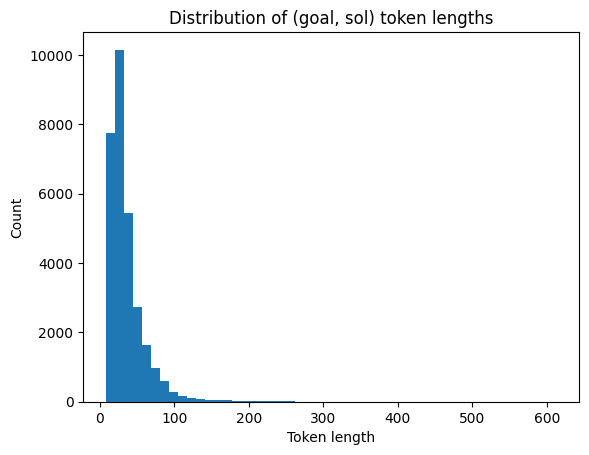

In [12]:
import matplotlib.pyplot as plt

lengths = []
for ex in train_ds:
    for sol_key in ["sol1", "sol2"]:
        enc = tokenizer(ex["goal"], ex[sol_key], truncation=False)
        lengths.append(len(enc["input_ids"]))

lengths = np.array(lengths)
print(f"min={lengths.min()}  mean={lengths.mean():.1f} p90={np.percentile(lengths, 90):.0f} p95={np.percentile(lengths, 95):.0f} p99={np.percentile(lengths, 99):.0f} max={lengths.max()}")

plt.hist(lengths, bins=50)
plt.xlabel("Token length")
plt.ylabel("Count")
plt.title("Distribution of (goal, sol) token lengths")
plt.show()


### 3.4 PyTorch Dataset


In [13]:
MAX_LEN = 128  # p95 ≈ 81 tokens; 128 = next power of 2 (see Token-length audit)

class PIQADataset(Dataset):
    def __init__(self, hf_dataset, tokenizer, max_len=MAX_LEN):
        self.data = hf_dataset
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        ex = self.data[idx]
        enc1 = self.tokenizer(
            ex["goal"], ex["sol1"],
            truncation=True, max_length=self.max_len,
            padding="max_length", return_tensors="pt",
        )
        enc2 = self.tokenizer(
            ex["goal"], ex["sol2"],
            truncation=True, max_length=self.max_len,
            padding="max_length", return_tensors="pt",
        )
        return {
            "input_ids_1":      enc1["input_ids"].squeeze(0),
            "attention_mask_1": enc1["attention_mask"].squeeze(0),
            "input_ids_2":      enc2["input_ids"].squeeze(0),
            "attention_mask_2": enc2["attention_mask"].squeeze(0),
            "label":            torch.tensor(ex["label"], dtype=torch.long),
        }


### Analytical batch-size estimate

Estimate dominant per-example training memory (attention scores + saved hidden activations) and divide by the available memory budget. Approximate but instant — gives a starting `BATCH_SIZE` that the empirical probe in Section 4.4 then validates.


In [14]:
# Memory model (per example, fp16 estimate, siamese ×2):
#   attention   = 2 · L · H · T² · 2 bytes
#   hidden act. = 2 · L · T · D · ~10 saved tensors · 2 bytes
# Fixed overhead = params + grads + AdamW(m, v) ≈ 4× params in fp32.
# fp16 used ONLY for the estimate — real training is fp32/bf16 (RoBERTa is unstable in fp16).
from transformers import AutoConfig

cfg = AutoConfig.from_pretrained(PRETRAINED_MODEL_NAME)
L, H, D, T = cfg.num_hidden_layers, cfg.num_attention_heads, cfg.hidden_size, MAX_LEN
n_params = 82_000_000
BYTES_PER_ELEM = 2

attn_bytes   = 2 * L * H * T * T * BYTES_PER_ELEM
hidden_bytes = 2 * L * T * D * 10 * BYTES_PER_ELEM
per_example  = attn_bytes + hidden_bytes
fixed_bytes  = n_params * 4 * 4

if device.type == "cuda":
    total = torch.cuda.get_device_properties(0).total_memory
    usable = int(total * 0.85)
elif device.type == "mps":
    usable = 8 * 1024**3
else:
    BATCH_SIZE = 8
    print(f"Device: CPU — using BATCH_SIZE={BATCH_SIZE}")
    usable = None

if usable is not None:
    budget = max(0, usable - fixed_bytes)
    max_bs = max(1, budget // per_example)
    BATCH_SIZE = max(1, int(max_bs * 0.8))
    print(f"Device: {device.type.upper()}")
    print(f"  per-example activations: {per_example / 1024**2:.1f} MB")
    print(f"  fixed overhead:          {fixed_bytes / 1024**3:.2f} GB")
    print(f"  usable budget:           {usable / 1024**3:.2f} GB")
    print(f"  estimated max batch:     {max_bs}")
    print(f"  BATCH_SIZE (80% margin): {BATCH_SIZE}")

MAX_BATCH_SIZE = max_bs


Device: CUDA
  per-example activations: 27.0 MB
  fixed overhead:          1.22 GB
  usable budget:           26.66 GB
  estimated max batch:     964
  BATCH_SIZE (80% margin): 771


## 4. Model


### Decisions and justifications

| Decision | Choice | Why |
|---|---|---|
| Pretrained checkpoint | `distilroberta-base` (82M params, Apache-2.0) | 6-layer distillation of RoBERTa-base — small enough to sweep on a single 5090 / MPS, large enough to be a credible "pretrained Transformer". Cased + byte-level BPE matches the tokenizer already chosen in Section 3. |
| Shared architecture (Models 1 & 2) | 6 encoder layers, hidden 768, 12 attention heads, FFN 3072, GELU, dropout 0.1, LayerNorm-eps 1e-5, max_pos 514, vocab 50 265 | Read directly from `AutoConfig.from_pretrained("distilroberta-base")` — kept identical between random and pretrained per project spec so the only difference is initialization. |
| Backbone wrapper | `AutoModel` with `add_pooling_layer=False` | The RoBERTa `pooler` (Linear + tanh on `<s>`) was trained for NSP and is widely reported to hurt fine-tuning; HF's own `RobertaForSequenceClassification` ignores it. Dropping it removes ~0.6M unused params and keeps Model 1 / Model 2 strictly equivalent. |
| Pooling | First token (`<s>`) of `last_hidden_state` | Standard RoBERTa fine-tuning convention; `<s>` is the only position guaranteed to attend over the full sequence after self-attention. |
| Classifier head | `Dropout(p)` → `Linear(768 → 1)` (scalar score per candidate) | Smallest possible head — any gap between Models 1 and 2 is attributable to the encoder, not classifier capacity. |
| MCQ formulation | **Siamese**: encode each `(goal, sol_i)` independently with the shared backbone, stack the two scalar scores → `(B, 2)` logits, softmax + cross-entropy | Standard PIQA / multiple-choice setup (mirrors `RobertaForMultipleChoice`). Avoids position bias from concatenating both candidates in one sequence and lets us reuse the Section 3 siamese encoding. |
| Param count | Random ≈ Pretrained ≈ 81.5M backbone + 769 head | Sanity-check that Models 1 and 2 are truly architecturally identical. |
| LLM choice | **Claude Sonnet 4.6** via the Anthropic API (`claude-sonnet-4-6`) | Meets the ≥1B-param spec with significant headroom (frontier-tier instruct model); no local GPU memory cost; prompt-engineered only (no finetuning) per project rules. Scoring is **text-parsed** ("A"/"B") rather than log-prob — the Messages API does not expose logits. Haiku 4.5 was evaluated head-to-head and lost on every prompt strategy, so the reported numbers all use Sonnet. |


### 4.1 Shared classifier


In [15]:
class TransformerClassifier(nn.Module):
    """Siamese MCQ head: shared backbone scores each (goal, sol) pair; the two
    scalar scores are stacked into (B, 2) logits."""

    def __init__(self, backbone, dropout: float = 0.1):
        super().__init__()
        self.backbone = backbone
        hidden = backbone.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.score = nn.Linear(hidden, 1)

    def _score_pair(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        return self.score(self.dropout(cls)).squeeze(-1)

    def forward(self, input_ids_1, attention_mask_1,
                      input_ids_2, attention_mask_2):
        s1 = self._score_pair(input_ids_1, attention_mask_1)
        s2 = self._score_pair(input_ids_2, attention_mask_2)
        return torch.stack([s1, s2], dim=1)


### 4.2 Model 1 — randomly initialized


In [16]:
from transformers import AutoConfig, AutoModel

config_random   = AutoConfig.from_pretrained(PRETRAINED_MODEL_NAME)
backbone_random = AutoModel.from_config(config_random, add_pooling_layer=False)

set_seed(42)
model_random = TransformerClassifier(
    backbone_random,
    dropout=config_random.hidden_dropout_prob,
).to(device)

n_total = sum(p.numel() for p in model_random.parameters())
n_back  = sum(p.numel() for p in model_random.backbone.parameters())
print(f"Model 1 (random)     | backbone: {n_back:,}  total: {n_total:,}")


Model 1 (random)     | backbone: 81,527,808  total: 81,528,577


### 4.3 Model 2 — pretrained


In [17]:
from transformers import AutoModel

backbone_pretrained = AutoModel.from_pretrained(
    PRETRAINED_MODEL_NAME, add_pooling_layer=False,
)

model_pretrained = TransformerClassifier(
    backbone_pretrained,
    dropout=backbone_pretrained.config.hidden_dropout_prob,
).to(device)

n_total = sum(p.numel() for p in model_pretrained.parameters())
n_back  = sum(p.numel() for p in model_pretrained.backbone.parameters())
print(f"Model 2 (pretrained) | backbone: {n_back:,}  total: {n_total:,}")

assert sum(p.numel() for p in model_random.parameters()) == n_total

print()
print(model_pretrained.backbone.config)


Model 2 (pretrained) | backbone: 81,527,808  total: 81,528,577

RobertaConfig {
  "architectures": [
    "RobertaForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 6,
  "pad_token_id": 1,
  "position_embedding_type": "absolute",
  "transformers_version": "4.57.6",
  "type_vocab_size": 1,
  "use_cache": true,
  "vocab_size": 50265
}



### Forward shape + softmax check

One forward pass through Model 2. Assert logits have shape `(B, 2)` and that softmax sums to 1. Catches CLS-pool, head-shape, and double-softmax bugs.


In [18]:
probe_loader = DataLoader(PIQADataset(valid_ds, tokenizer), batch_size=4)
batch = next(iter(probe_loader))
batch = {k: v.to(device) for k, v in batch.items()}

model_pretrained.eval()
with torch.no_grad():
    logits = model_pretrained(
        batch["input_ids_1"], batch["attention_mask_1"],
        batch["input_ids_2"], batch["attention_mask_2"],
    )

probs = torch.softmax(logits, dim=-1)
assert logits.shape == (4, 2),                     f"expected (4, 2), got {tuple(logits.shape)}"
assert torch.allclose(probs.sum(-1), torch.ones(4, device=device), atol=1e-5)
print(f"logits shape: {tuple(logits.shape)}    softmax sums: {probs.sum(-1).tolist()}")


logits shape: (4, 2)    softmax sums: [1.0, 1.0, 1.0, 1.0]


### 4.4 Batch size probe + DataLoaders


first sainity check for `BATCH_SIZE` (not used afterwards)

In [19]:
def find_max_batch_size(model, max_len, device,
                        candidates=(8, 16, 32, 64, 128, 256)):
    """Empirical probe: largest BS that survives one fwd+bwd on this device."""
    vocab = model.backbone.config.vocab_size
    ok = candidates[0]
    for bs in candidates:
        try:
            ids  = torch.randint(0, vocab, (bs, max_len), device=device)
            mask = torch.ones_like(ids)
            model.train()
            loss = model(ids, mask, ids, mask).sum()
            loss.backward()
            model.zero_grad(set_to_none=True)
            if device.type == "cuda": torch.cuda.empty_cache()
            elif device.type == "mps": torch.mps.empty_cache()
            ok = bs
            print(f"  bs={bs:4d}  OK")
        except (RuntimeError, MemoryError) as e:
            print(f"  bs={bs:4d}  FAIL ({type(e).__name__}: {str(e)[:60]})")
            break
    return ok

probed = find_max_batch_size(model_pretrained, MAX_LEN, device)
BATCH_SIZE = min(BATCH_SIZE, probed)
print(f"\nFinal BATCH_SIZE = {BATCH_SIZE}")


  bs=   8  OK
  bs=  16  OK
  bs=  32  OK
  bs=  64  OK
  bs= 128  OK
  bs= 256  OK

Final BATCH_SIZE = 256


In [20]:
pin = (device.type == "cuda")
nw  = 2 if device.type == "cuda" else 0  # MPS multi-worker loaders are buggy

train_loader = DataLoader(PIQADataset(train_ds, tokenizer),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=nw, pin_memory=pin, drop_last=False)
valid_loader = DataLoader(PIQADataset(valid_ds, tokenizer),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=nw, pin_memory=pin)
test_loader  = DataLoader(PIQADataset(test_ds, tokenizer),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=nw, pin_memory=pin)

print(f"train batches: {len(train_loader)}   valid: {len(valid_loader)}   test: {len(test_loader)}")


train batches: 60   valid: 4   test: 8


### 4.5 Model 3 — LLM

Claude Sonnet 4.6 via the Anthropic Messages API. No finetuning, prompt engineering only. Section 5.4 compares four strategies on the validation set (`zero_shot`, `few_shot_4`, `sophisticated_cot`, `sophisticated_cot_carrot`); the winner is the one scored on test in Section 6. (Same four strategies were also run on Haiku 4.5 — Sonnet won on each, so Haiku is not reported below.)


In [21]:
import anthropic

LLM_NAME = "claude-sonnet-4-6"

anthropic_client = anthropic.Anthropic()  # reads ANTHROPIC_API_KEY from env
print(f"LLM client ready: {LLM_NAME}")


LLM client ready: claude-sonnet-4-6


**Four prompt-engineering strategies.** All compared on the validation set; the highest-val_acc strategy is run on test in Section 6.

1. `zero_shot` — terse system prompt, single-letter output.
2. `few_shot_4` — same instructions + 4 in-context demos (label-balanced).
3. `sophisticated_cot` — reasoning rubric + chain-of-thought.
4. `sophisticated_cot_carrot` — same as (3) plus a "$200 reward" carrot.


In [22]:
import re
from dataclasses import dataclass
from typing import Callable

# --- Few-shot demos: deterministic, label-balanced, interleaved A/B/A/B ---
def _pick_demo_examples(n=4):
    half = n // 2
    a_ex, b_ex = [], []
    for i in range(len(train_ds)):
        ex = train_ds[i]
        if ex["label"] == 0 and len(a_ex) < half: a_ex.append(ex)
        elif ex["label"] == 1 and len(b_ex) < half: b_ex.append(ex)
        if len(a_ex) == half and len(b_ex) == half: break
    out = []
    for a, b in zip(a_ex, b_ex):
        out.extend([a, b])
    return out

FEW_SHOT_DEMOS = _pick_demo_examples(4)

# --- System prompts ---
SYSTEM_TERSE = (
    "You answer physical commonsense multiple-choice questions. "
    "Each question has a goal and two candidate solutions labeled A and B. "
    "Reply with ONLY the single letter A or B — no explanation, no punctuation, no extra text."
)

SYSTEM_SOPHISTICATED = (
    "You are an expert at physical commonsense reasoning about everyday tasks. "
    "Each question gives a goal and two candidate solutions labeled A and B. "
    "Exactly one is practically correct; the other has a subtle flaw "
    "(wrong material, ineffective step, unsafe, or physically infeasible).\n\n"
    "Reasoning checklist before answering:\n"
    "  - What is the goal actually asking for?\n"
    "  - Are the materials/tools appropriate?\n"
    "  - Does the procedure produce the intended physical outcome?\n"
    "  - Is the procedure safe and feasible?\n\n"
    "Think step by step in 3–6 short sentences, then output your final answer "
    "on its own line in the EXACT format:  Answer: A   or   Answer: B"
)

SYSTEM_SOPHISTICATED_CARROT = (
    SYSTEM_SOPHISTICATED
    + "\n\nIMPORTANT: This task is part of a high-stakes evaluation. "
    "For every question you answer correctly you earn a $200 reward — "
    "your careful reasoning genuinely matters here. Take the time to think."
)

# --- User-message builders ---
def _build_user_plain(goal, sol1, sol2):
    return f"Goal: {goal}\nA) {sol1}\nB) {sol2}"

def _build_user_fewshot(goal, sol1, sol2):
    parts = ["Here are some worked examples:\n"]
    for ex in FEW_SHOT_DEMOS:
        ans = "A" if ex["label"] == 0 else "B"
        parts.append(f"Goal: {ex['goal']}\nA) {ex['sol1']}\nB) {ex['sol2']}\nAnswer: {ans}\n")
    parts.append("Now answer this one:\n" + _build_user_plain(goal, sol1, sol2))
    return "\n".join(parts)

# --- Parsers ---
def _parse_first_letter(text):
    for ch in text.strip().upper():
        if ch == "A": return 0
        if ch == "B": return 1
    return None

_ANSWER_RE = re.compile(r"Answer\s*:\s*([AB])", re.IGNORECASE)
def _parse_answer_line(text):
    m = _ANSWER_RE.search(text)
    if m: return 0 if m.group(1).upper() == "A" else 1
    matches = re.findall(r"(?<![A-Za-z])([AB])(?![A-Za-z])", text.upper())
    if matches: return 0 if matches[-1] == "A" else 1
    return None

@dataclass
class PromptStrategy:
    name: str
    system: str
    build_user: Callable
    parser: Callable
    max_tokens: int

STRATEGIES = {
    "zero_shot": PromptStrategy(
        name="zero_shot", system=SYSTEM_TERSE,
        build_user=_build_user_plain, parser=_parse_first_letter, max_tokens=4,
    ),
    "few_shot_4": PromptStrategy(
        name="few_shot_4", system=SYSTEM_TERSE,
        build_user=_build_user_fewshot, parser=_parse_first_letter, max_tokens=4,
    ),
    "sophisticated_cot": PromptStrategy(
        name="sophisticated_cot", system=SYSTEM_SOPHISTICATED,
        build_user=_build_user_plain, parser=_parse_answer_line, max_tokens=400,
    ),
    "sophisticated_cot_carrot": PromptStrategy(
        name="sophisticated_cot_carrot", system=SYSTEM_SOPHISTICATED_CARROT,
        build_user=_build_user_plain, parser=_parse_answer_line, max_tokens=400,
    ),
}

# Eyeball one rendering per strategy.
ex = train_ds[0]
for name, s in STRATEGIES.items():
    user = s.build_user(ex["goal"], ex["sol1"], ex["sol2"])
    print(f"=== {name}  (max_tokens={s.max_tokens})")
    print(f"-- system ({len(s.system)} chars) --")
    print(s.system[:240] + ("…" if len(s.system) > 240 else ""))
    print(f"-- user ({len(user)} chars) --")
    print(user[:320] + ("…" if len(user) > 320 else ""))
    print()


=== zero_shot  (max_tokens=4)
-- system (218 chars) --
You answer physical commonsense multiple-choice questions. Each question has a goal and two candidate solutions labeled A and B. Reply with ONLY the single letter A or B — no explanation, no punctuation, no extra text.
-- user (97 chars) --
Goal: When boiling butter, when it's ready, you can
A) Pour it onto a plate
B) Pour it into a jar

=== few_shot_4  (max_tokens=4)
-- system (218 chars) --
You answer physical commonsense multiple-choice questions. Each question has a goal and two candidate solutions labeled A and B. Reply with ONLY the single letter A or B — no explanation, no punctuation, no extra text.
-- user (789 chars) --
Here are some worked examples:

Goal: To permanently attach metal legs to a chair, you can
A) Weld the metal together to get it to stay firmly in place
B) Nail the metal together to get it to stay firmly in place
Answer: A

Goal: When boiling butter, when it's ready, you can
A) Pour it onto a plate
B) Pour

## 5. Training


### Decisions and justifications

| Decision | Choice | Why |
|---|---|---|
| Loss | CrossEntropy over the 2 candidate scores | Standard MCQ formulation; consistent with the siamese head from Section 4.1. |
| Optimizer | AdamW | Decoupled weight decay, default for Transformer fine-tuning |
| Tuning protocol | 5-epoch grid sweep → top-3 → 20 epochs (no early stopping anywhere) | Fixed-budget runs make configs directly comparable; longer re-training on the top 3 exposes which configs actually scale with more compute. WSD was on the schedule grid initially but produced no top-3 winner and was dropped to halve sweep cost. |
| **LR grid (random)** | `[1e-4, 3e-4, 1e-3, 3e-3]` | Half-decade log spacing (×√10 ≈ ×3.16), the textbook step for an LR sweep — finer than ×10 (which misses the curve shape), coarser than ×2 (which overfits to per-run noise without seed averaging). Centred at `3e-4`, the Vaswani-2017 default for small Transformers from scratch. `1e-4` is a "probably too slow in 5 epochs" anchor; `3e-3` is an "expected to diverge" anchor that bounds the upper end (visible in the `grad_norm` log). |
| **LR grid (pretrained)** | `[3e-6, 1e-5, 3e-5, 1e-4]` | Same half-decade spacing as the random grid, shifted **exactly one decade down**. Centred at `3e-5`, the RoBERTa fine-tuning sweet spot (Liu et al., 2019). `3e-6` is a "definitely too slow" lower anchor; `1e-4` reaches catastrophic-forgetting territory. The exact one-decade offset makes the "pretraining shifts the LR optimum down ~10×" claim in Section 7 directly falsifiable from the W&B charts. |
| **LR schedule grid** | `["cosine", "constant_with_warmup"]` | Two-way shape contrast: smooth decay (cosine — the de-facto fine-tuning default) vs no decay at all (constant-with-warmup — does decay even help at this scale?). Identical across architectures so we can ask "does the preferred schedule flip between random and pretrained?" in Section 7. |
| **Weight-decay grid (random)** | `[1e-2, 5e-2]` | Both points include regularization — `0` deliberately excluded because random-from-scratch on 15K examples without weight decay tends to overfit visibly within 5 epochs. `1e-2` is the AdamW default; `5e-2` is the upper end of common from-scratch recipes. |
| **Weight-decay grid (pretrained)** | `[0.0, 1e-2]` | The meaningful contrast for fine-tuning: does decay help *on top of* MLM-pretrained features that are already implicitly regularized? `1e-2` is the RoBERTa fine-tuning standard. |
| **Dropout grid (random)** | `[0.1, 0.3]` | `0.1` is the RoBERTa default (lower bound); `0.3` is heavy regularization for the small-data from-scratch regime where the random init gives no inductive prior. Applied symmetrically to backbone and head. |
| **Dropout grid (pretrained)** | `[0.2, 0.4]` | Both above the pretraining default of `0.1` — PIQA is small (15K) and DistilRoBERTa is 82M, so overfitting dominates during fine-tuning. `0.2` is a modest uptick; `0.4` stress-tests heavy regularization on pretrained features. |
| Warmup ratio | Fixed at 10% of total steps | Out of the sweep — AdamW Transformer default, lower-impact than LR / schedule. |
| Epochs (sweep) | 5, no early stopping | Short enough to make the grid tractable; full enough that pretrained runs reach near-final accuracy. |
| Epochs (full re-train) | 20, no early stopping | Gives the top-3 configs room to either converge or visibly overfit. |
| Batch size | Empirical max from Section 4.4 probe | Largest BS that fits in VRAM. Not swept — too expensive and not expected to flip the LR/schedule winner. |
| Gradient clip | `1.0` (global norm) | Stabilizes Transformer training, especially in the high-LR random runs. `grad_norm` logged each epoch surfaces divergent configs. |
| Precision | fp32 everywhere | Stable on both MPS and CUDA without extra complexity. |
| Early stopping | **Disabled** in both stages | Fixed-budget runs only, so a config's score is "what it reaches in N epochs". |
| Checkpointing | `torch.save(model.state_dict(), …)` on best `peak_val_acc`; uploaded via `wandb.save` | Single best-loss checkpoint per run. |
| Final-model selection | Highest `peak_val_acc` across the top-3 full re-train runs, per architecture | The chosen checkpoint becomes `model_random` / `model_pretrained` used in Section 6. |
| Extra W&B metrics | `grad_norm`, `val_pred_a_rate`, `epoch_seconds` (per epoch); `peak_val_acc`, `peak_val_acc_epoch`, `trained_param_count` (summary) | `grad_norm` flags divergent high-LR configs; `val_pred_a_rate` exposes positional shortcuts (50% = no bias); summary fields are sortable columns in the W&B table. |

**Design principle.** The two architectures face different regimes — from-scratch on small data (overfitting + init noise) vs. fine-tuning a pretrained encoder (catastrophic forgetting). The grid axes are kept **identical** (same knobs, same points per axis) so the cross-architecture comparison is structurally clean; the **value lists per axis are tuned per regime** rather than inherited blindly.


### 5.1 Train / eval loops


In [23]:
def _forward(model, batch):
    return model(batch["input_ids_1"], batch["attention_mask_1"],
                 batch["input_ids_2"], batch["attention_mask_2"])

def train_epoch(model, loader, optimizer, scheduler, device, max_grad_norm=1.0):
    """Train one epoch. Returns (loss, acc, mean pre-clip grad norm)."""
    model.train()
    criterion = nn.CrossEntropyLoss()
    total_loss, total_correct, total_n = 0.0, 0, 0
    total_grad_norm, n_steps = 0.0, 0
    for batch in loader:
        batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
        logits = _forward(model, batch)
        loss = criterion(logits, batch["label"])

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        total_grad_norm += float(grad_norm)
        n_steps += 1
        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        bs = batch["label"].size(0)
        total_loss    += loss.item() * bs
        total_correct += (logits.argmax(-1) == batch["label"]).sum().item()
        total_n       += bs
    return total_loss / total_n, total_correct / total_n, total_grad_norm / max(1, n_steps)

@torch.no_grad()
def evaluate(model, loader, device):
    """Evaluate. Returns (loss, acc, predicted-A rate) — pred_a_rate flags position bias."""
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, total_correct, total_n, n_pred_a = 0.0, 0, 0, 0
    for batch in loader:
        batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
        logits = _forward(model, batch)
        loss = criterion(logits, batch["label"])
        preds = logits.argmax(-1)
        bs = batch["label"].size(0)
        total_loss    += loss.item() * bs
        total_correct += (preds == batch["label"]).sum().item()
        n_pred_a      += (preds == 0).sum().item()
        total_n       += bs
    return total_loss / total_n, total_correct / total_n, n_pred_a / total_n


In [24]:
import time
from transformers import (
    get_linear_schedule_with_warmup,
    get_cosine_schedule_with_warmup,
    get_constant_schedule_with_warmup,
)

CKPT_DIR = "checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

def _build_scheduler(lr_schedule, optimizer, warmup_steps, total_steps):
    if lr_schedule == "cosine":
        return get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    if lr_schedule == "constant_with_warmup":
        return get_constant_schedule_with_warmup(optimizer, warmup_steps)
    if lr_schedule == "linear":
        return get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    raise ValueError(f"unknown lr_schedule: {lr_schedule!r}")

def _fmt(v):
    if v == 0: return "0"
    exp = int(math.floor(math.log10(abs(v))))
    mant = v / (10 ** exp)
    return f"{int(round(mant))}e{exp}" if abs(mant - round(mant)) < 1e-9 else f"{mant:.1f}e{exp}"

def make_run_name(prefix, lr, lr_schedule, dropout, weight_decay, epochs):
    return (f"{prefix}___lr_{_fmt(lr)}___lr_schedule_{lr_schedule}"
            f"___dropout_{dropout}___wd_{_fmt(weight_decay)}___ep{epochs}")

def run_training(model, prefix, train_loader, valid_loader,
                 lr, weight_decay, num_epochs,
                 lr_schedule="cosine", warmup_ratio=0.1,
                 dropout=0.1, patience=2, early_stopping=True,
                 save_ckpt=True):
    """Train `model` and return a result dict.

    Saves the best-`val_loss` checkpoint to disk and loads it back at the end.
    With `early_stopping=False` the run goes the full `num_epochs` — used by
    the Section 5.2 / Section 5.3 sweeps so every config is compared on equal footing.

    Per-epoch W&B keys: train/val loss & acc, learning_rate, grad_norm,
    val_pred_a_rate, epoch_seconds. Summary: peak_val_acc, peak_val_acc_epoch,
    trained_param_count.
    """
    run_name = make_run_name(prefix, lr, lr_schedule, dropout, weight_decay, num_epochs)
    ckpt_path = os.path.join(CKPT_DIR, f"{run_name}.pt")
    n_params = sum(p.numel() for p in model.parameters())

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps  = num_epochs * len(train_loader)
    warmup_steps = int(warmup_ratio * total_steps)
    scheduler = _build_scheduler(lr_schedule, optimizer, warmup_steps, total_steps)

    wandb.init(
        entity="benjamin-amhof-hochschule-luzern",
        project="NLP_Transformers",
        name=run_name, reinit="finish_previous",
        config={"prefix": prefix, "lr": lr, "lr_schedule": lr_schedule,
                "dropout": dropout, "weight_decay": weight_decay,
                "epochs": num_epochs, "batch_size": train_loader.batch_size,
                "max_len": MAX_LEN, "warmup_ratio": warmup_ratio,
                "early_stopping": early_stopping,
                "trained_param_count": n_params,
                "model_name": PRETRAINED_MODEL_NAME},
    )

    best_val_loss, best_val_acc, best_epoch = float("inf"), 0.0, -1
    patience_left = patience
    for epoch in range(1, num_epochs + 1):
        t0 = time.perf_counter()
        tr_loss, tr_acc, grad_norm        = train_epoch(model, train_loader, optimizer, scheduler, device)
        va_loss, va_acc, val_pred_a_rate  = evaluate(model, valid_loader, device)
        epoch_seconds = time.perf_counter() - t0

        wandb.log({"train_loss": tr_loss, "train_acc": tr_acc,
                   "val_loss":   va_loss, "val_acc":   va_acc,
                   "learning_rate": optimizer.param_groups[0]["lr"],
                   "grad_norm": grad_norm,
                   "val_pred_a_rate": val_pred_a_rate,
                   "epoch_seconds": epoch_seconds}, step=epoch)
        print(f"  ep {epoch:2d}  train {tr_loss:.4f}/{tr_acc:.3f}   "
              f"val {va_loss:.4f}/{va_acc:.3f}   "
              f"|g|={grad_norm:.2f}  pred_A={val_pred_a_rate:.2f}  {epoch_seconds:.1f}s")

        # Track val_loss for the summary, but checkpoint on val_acc — the
        # metric used for sweep + final-model selection.
        if va_loss < best_val_loss:
            best_val_loss = va_loss
        if va_acc > best_val_acc:
            best_val_acc, best_epoch = va_acc, epoch
            if save_ckpt:
                torch.save(model.state_dict(), ckpt_path)
            patience_left = patience
        else:
            patience_left -= 1
            if early_stopping and patience_left <= 0:
                print(f"  early stop at epoch {epoch}  (best ep {best_epoch})")
                break

    wandb.run.summary["peak_val_acc"]        = best_val_acc
    wandb.run.summary["peak_val_acc_epoch"]  = best_epoch
    wandb.run.summary["trained_param_count"] = n_params

    if save_ckpt:
        wandb.save(ckpt_path, base_path=".")
    wandb.finish()

    if save_ckpt:
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
    return {"run_name": run_name, "best_epoch": best_epoch,
            "best_val_loss": best_val_loss, "best_val_acc": best_val_acc,
            "ckpt_path": ckpt_path if save_ckpt else None,
            "lr": lr, "weight_decay": weight_decay, "dropout": dropout,
            "lr_schedule": lr_schedule, "num_epochs": num_epochs}


### Overfit test

Train Model 1 & 2 on a 32-example slice for ~50 epochs (terminated when `train_acc ≥ 0.95`). If the model cannot memorize 32 examples, the bug is in the pipeline. Additional check for `lr_schedule` later planned to use.


In [49]:
import copy

small_ds     = PIQADataset(train_ds.select(range(32)), tokenizer)
small_loader = DataLoader(small_ds, batch_size=8, shuffle=True)

EPOCHS    = 50
THRESH    = 0.95
SCHEDULES = ["cosine", "constant_with_warmup"]
MODELS    = [("random", model_random), ("pretrained", model_pretrained)]

for name, model in MODELS:
    for sched_name in SCHEDULES:
        print(f"\n=== Overfitting test: {name} model  |  sched={sched_name} ===")
        overfit_model = copy.deepcopy(model)
        opt = torch.optim.AdamW(overfit_model.parameters(), lr=1e-4)

        total_steps  = EPOCHS * len(small_loader)
        warmup_steps = int(0.1 * total_steps)
        sched = _build_scheduler(sched_name, opt, warmup_steps, total_steps)

        last_acc = 0.0
        for ep in range(1, EPOCHS + 1):
            _, last_acc, _ = train_epoch(overfit_model, small_loader, opt, sched, device)
            if ep % 5 == 0:
                print(f"  ep {ep:2d}  train_acc {last_acc:.3f}")
            if last_acc >= THRESH:
                print(f"OK   reached train_acc={last_acc:.3f} at ep {ep} — stopping early")
                break
        else:
            print(f"WARNING: final train_acc={last_acc:.3f} did not reach >{int(THRESH*100)}% — "
                  "overfitting may have failed, results may be unreliable!")

        del overfit_model, opt, sched



=== Overfitting test: random model  |  sched=cosine ===
  ep  5  train_acc 0.406
  ep 10  train_acc 0.781
  ep 15  train_acc 0.875
  ep 20  train_acc 0.906
  ep 25  train_acc 0.781
  ep 30  train_acc 0.844
OK   reached train_acc=0.969 at ep 32 — stopping early

=== Overfitting test: random model  |  sched=constant_with_warmup ===
  ep  5  train_acc 0.438
  ep 10  train_acc 0.625
  ep 15  train_acc 0.750
  ep 20  train_acc 0.844
  ep 25  train_acc 0.875
  ep 30  train_acc 0.844
  ep 35  train_acc 0.750
  ep 40  train_acc 0.781
  ep 45  train_acc 0.844
  ep 50  train_acc 0.906

=== Overfitting test: pretrained model  |  sched=cosine ===
  ep  5  train_acc 0.219
  ep 10  train_acc 0.656
  ep 15  train_acc 0.594
  ep 20  train_acc 0.719
  ep 25  train_acc 0.844
OK   reached train_acc=1.000 at ep 27 — stopping early

=== Overfitting test: pretrained model  |  sched=constant_with_warmup ===
  ep  5  train_acc 0.562
  ep 10  train_acc 0.719
  ep 15  train_acc 0.812
OK   reached train_acc=1.0

### 5.2 Hyperparameter tuning — Model 1 (random)

Two-stage protocol (no early stopping in either stage):

1. **5-epoch grid sweep** over `lr × lr_schedule × weight_decay × dropout` — 32 configs.
2. **Top-3 full re-train** — the 3 highest-`peak_val_acc` configs are re-trained for 20 epochs each.

The 20-epoch run with the highest `peak_val_acc` becomes the final `model_random` used in Section 6.


In [ ]:
SWEEP_GRID_RANDOM = {
    "lr":           [1e-4, 3e-4, 1e-3, 3e-3],
    "lr_schedule":  ["cosine", "constant_with_warmup"],
    "weight_decay": [1e-2, 5e-2],
    "dropout":      [0.1, 0.3],
}

In [ ]:
def grid_configs(grid):
    keys = list(grid)
    for vals in itertools.product(*[grid[k] for k in keys]):
        yield dict(zip(keys, vals))

SWEEP_EPOCHS = 5

def make_random_model():
    """Fresh random-init Model 1 — reseeded per call so all configs share the
    same backbone initialization, isolating the effect of the swept hparams."""
    set_seed(42)
    cfg = AutoConfig.from_pretrained(PRETRAINED_MODEL_NAME)
    cfg.hidden_dropout_prob = dropout
    cfg.attention_probs_dropout_prob = dropout
    backbone = AutoModel.from_config(cfg, add_pooling_layer=False)
    return TransformerClassifier(backbone, dropout=dropout).to(device)

SWEEP_GRID_RANDOM = SWEEP_GRID_RANDOM

# Resume support: each finished sweep run writes its metrics to
# checkpoints/{run_name}.json — rerunning skips configs whose JSON exists.
# save_ckpt=False avoids the 312 MB .pt write per config.
sweep_results_random = []
for cfg in grid_configs(SWEEP_GRID_RANDOM):
    run_name = make_run_name("random_sweep", cfg["lr"], cfg["lr_schedule"],
                             cfg["dropout"], cfg["weight_decay"], SWEEP_EPOCHS)
    sidecar = os.path.join(CKPT_DIR, f"{run_name}.json")
    if os.path.exists(sidecar):
        with open(sidecar) as f:
            sweep_results_random.append(json.load(f))
        print(f"=== random sweep  {cfg}  [resumed from sidecar]")
        continue

    print(f"\n=== random sweep  {cfg}")
    m = make_random_model(dropout=cfg["dropout"])
    res = run_training(
        m, prefix="random_sweep",
        train_loader=train_loader, valid_loader=valid_loader,
        lr=cfg["lr"], weight_decay=cfg["weight_decay"], num_epochs=SWEEP_EPOCHS,
        lr_schedule=cfg["lr_schedule"], dropout=cfg["dropout"],
        early_stopping=False, save_ckpt=False,
    )
    with open(sidecar, "w") as f:
        json.dump(res, f, indent=2)
    sweep_results_random.append(res)

sweep_results_random.sort(key=lambda r: r["best_val_acc"], reverse=True)
print("\n--- 5-epoch sweep ranking (Model 1 random) ---")
for r in sweep_results_random:
    print(f"  val_acc={r['best_val_acc']:.4f}  lr={r['lr']:.0e}  "
          f"sched={r['lr_schedule']:6s}  wd={r['weight_decay']:.0e}  drop={r['dropout']}")


=== random sweep  {'lr': 0.0001, 'lr_schedule': 'cosine', 'weight_decay': 0.01, 'dropout': 0.1}  [resumed from sidecar]
=== random sweep  {'lr': 0.0001, 'lr_schedule': 'cosine', 'weight_decay': 0.01, 'dropout': 0.3}  [resumed from sidecar]
=== random sweep  {'lr': 0.0001, 'lr_schedule': 'cosine', 'weight_decay': 0.05, 'dropout': 0.1}  [resumed from sidecar]
=== random sweep  {'lr': 0.0001, 'lr_schedule': 'cosine', 'weight_decay': 0.05, 'dropout': 0.3}  [resumed from sidecar]
=== random sweep  {'lr': 0.0001, 'lr_schedule': 'constant_with_warmup', 'weight_decay': 0.01, 'dropout': 0.1}  [resumed from sidecar]
=== random sweep  {'lr': 0.0001, 'lr_schedule': 'constant_with_warmup', 'weight_decay': 0.01, 'dropout': 0.3}  [resumed from sidecar]
=== random sweep  {'lr': 0.0001, 'lr_schedule': 'constant_with_warmup', 'weight_decay': 0.05, 'dropout': 0.1}  [resumed from sidecar]
=== random sweep  {'lr': 0.0001, 'lr_schedule': 'constant_with_warmup', 'weight_decay': 0.05, 'dropout': 0.3}  [resume

#### 5.2.1 Top-3 full re-train (random)

The 3 highest-`peak_val_acc` configs from the sweep above, re-trained for 20 epochs each (still no early stopping). Winner by `peak_val_acc` becomes the final `model_random` used downstream.


In [31]:
TOP_K = 3
FULL_EPOCHS = 20

# Skip training if a finished W&B run for this exact config already exists.
WANDB_ENTITY  = "benjamin-amhof-hochschule-luzern"
WANDB_PROJECT = "NLP_Transformers"
_api = wandb.Api()
_finished_runs_cache = {r.name: r for r in _api.runs(f"{WANDB_ENTITY}/{WANDB_PROJECT}")
                        if r.state == "finished" and r.summary.get("peak_val_acc") is not None}

def _wandb_result_from_run(run, cfg, prefix, epochs):
    return {
        "run_name":      run.name,
        "best_epoch":    int(run.summary.get("peak_val_acc_epoch", -1)),
        "best_val_loss": float("inf"),
        "best_val_acc":  float(run.summary["peak_val_acc"]),
        "ckpt_path":     None,
        "lr":            cfg["lr"],        "weight_decay": cfg["weight_decay"],
        "dropout":       cfg["dropout"],   "lr_schedule":  cfg["lr_schedule"],
        "num_epochs":    epochs,
    }

full_results_random = []
for r in sweep_results_random[:TOP_K]:
    cfg = {"lr": r["lr"], "weight_decay": r["weight_decay"],
           "dropout": r["dropout"], "lr_schedule": r["lr_schedule"]}
    run_name = make_run_name("random_full", cfg["lr"], cfg["lr_schedule"],
                             cfg["dropout"], cfg["weight_decay"], FULL_EPOCHS)

    existing = _finished_runs_cache.get(run_name)
    if existing is not None:
        print(f"\n=== random full  {cfg}  [skipped — resumed from W&B run {existing.name}]")
        res = _wandb_result_from_run(existing, cfg, "random_full", FULL_EPOCHS)
    else:
        print(f"\n=== random full  {cfg}")
        m = make_random_model(dropout=cfg["dropout"])
        res = run_training(
            m, prefix="random_full",
            train_loader=train_loader, valid_loader=valid_loader,
            lr=cfg["lr"], weight_decay=cfg["weight_decay"], num_epochs=FULL_EPOCHS,
            lr_schedule=cfg["lr_schedule"], dropout=cfg["dropout"],
            early_stopping=False,
        )
    full_results_random.append(res)

best_random = max(full_results_random, key=lambda r: r["best_val_acc"])
print(f"\nFinal Model 1 (random): {best_random['run_name']}")
print(f"  best_val_acc={best_random['best_val_acc']:.4f}  best_epoch={best_random['best_epoch']}")

# Keep only the winning checkpoint; delete the other TOP_K-1 .pt files.
for r in full_results_random:
    if r["ckpt_path"] and r["ckpt_path"] != best_random["ckpt_path"]:
        if os.path.exists(r["ckpt_path"]):
            os.remove(r["ckpt_path"])
            print(f"  removed {r['run_name']}.pt")

# Local .pt is optional — Section 6 re-fetches the chosen run from W&B regardless.
if best_random["ckpt_path"] and os.path.exists(best_random["ckpt_path"]):
    model_random = make_random_model(dropout=best_random["dropout"])
    model_random.load_state_dict(torch.load(best_random["ckpt_path"], map_location=device))



=== random full  {'lr': 0.0001, 'weight_decay': 0.01, 'dropout': 0.1, 'lr_schedule': 'constant_with_warmup'}  [skipped — resumed from W&B run random_full___lr_1e-4___lr_schedule_constant_with_warmup___dropout_0.1___wd_1e-2___ep20]

=== random full  {'lr': 0.0001, 'weight_decay': 0.05, 'dropout': 0.1, 'lr_schedule': 'constant_with_warmup'}  [skipped — resumed from W&B run random_full___lr_1e-4___lr_schedule_constant_with_warmup___dropout_0.1___wd_5e-2___ep20]

=== random full  {'lr': 0.0001, 'weight_decay': 0.01, 'dropout': 0.3, 'lr_schedule': 'cosine'}  [skipped — resumed from W&B run random_full___lr_1e-4___lr_schedule_cosine___dropout_0.3___wd_1e-2___ep20]

Final Model 1 (random): random_full___lr_1e-4___lr_schedule_constant_with_warmup___dropout_0.1___wd_1e-2___ep20
  best_val_acc=0.5860  best_epoch=6


### 5.3 Hyperparameter tuning — Model 2 (pretrained)

Same protocol as Section 5.2: 32-config grid sweep at 5 epochs, then top-3 re-trained for 20 epochs. The pretrained grid uses lower learning rates to avoid catastrophic forgetting of the MLM-pretrained features.


In [ ]:
SWEEP_GRID_PRETRAINED = {
    "lr":           [3e-6, 1e-5, 3e-5, 1e-4],
    "lr_schedule":  ["cosine", "constant_with_warmup"],
    "weight_decay": [0.0, 1e-2],
    "dropout":      [0.2, 0.4],
}

In [ ]:
def make_pretrained_model():
    """Fresh pretrained Model 2 — backbone weights are deterministic (loaded
    from disk); reseeding only affects the random head Linear."""
    set_seed(42)
    backbone = AutoModel.from_pretrained(
        PRETRAINED_MODEL_NAME, add_pooling_layer=False,
        hidden_dropout_prob=dropout, attention_probs_dropout_prob=dropout,
    )
    return TransformerClassifier(backbone, dropout=dropout).to(device)

SWEEP_GRID_PRETRAINED = SWEEP_GRID_PRETRAINED

# Same sidecar-JSON resume pattern as Section 5.2.
sweep_results_pretrained = []
for cfg in grid_configs(SWEEP_GRID_PRETRAINED):
    run_name = make_run_name("pretrained_sweep", cfg["lr"], cfg["lr_schedule"],
                             cfg["dropout"], cfg["weight_decay"], SWEEP_EPOCHS)
    sidecar = os.path.join(CKPT_DIR, f"{run_name}.json")
    if os.path.exists(sidecar):
        with open(sidecar) as f:
            sweep_results_pretrained.append(json.load(f))
        print(f"=== pretrained sweep  {cfg}  [resumed from sidecar]")
        continue

    print(f"\n=== pretrained sweep  {cfg}")
    m = make_pretrained_model(dropout=cfg["dropout"])
    res = run_training(
        m, prefix="pretrained_sweep",
        train_loader=train_loader, valid_loader=valid_loader,
        lr=cfg["lr"], weight_decay=cfg["weight_decay"], num_epochs=SWEEP_EPOCHS,
        lr_schedule=cfg["lr_schedule"], dropout=cfg["dropout"],
        early_stopping=False, save_ckpt=False,
    )
    with open(sidecar, "w") as f:
        json.dump(res, f, indent=2)
    sweep_results_pretrained.append(res)

sweep_results_pretrained.sort(key=lambda r: r["best_val_acc"], reverse=True)
print("\n--- 5-epoch sweep ranking (Model 2 pretrained) ---")
for r in sweep_results_pretrained:
    print(f"  val_acc={r['best_val_acc']:.4f}  lr={r['lr']:.0e}  "
          f"sched={r['lr_schedule']:6s}  wd={r['weight_decay']:.0e}  drop={r['dropout']}")


=== pretrained sweep  {'lr': 3e-06, 'lr_schedule': 'cosine', 'weight_decay': 0.0, 'dropout': 0.2}  [resumed from sidecar]
=== pretrained sweep  {'lr': 3e-06, 'lr_schedule': 'cosine', 'weight_decay': 0.0, 'dropout': 0.4}  [resumed from sidecar]
=== pretrained sweep  {'lr': 3e-06, 'lr_schedule': 'cosine', 'weight_decay': 0.01, 'dropout': 0.2}  [resumed from sidecar]
=== pretrained sweep  {'lr': 3e-06, 'lr_schedule': 'cosine', 'weight_decay': 0.01, 'dropout': 0.4}  [resumed from sidecar]
=== pretrained sweep  {'lr': 3e-06, 'lr_schedule': 'constant_with_warmup', 'weight_decay': 0.0, 'dropout': 0.2}  [resumed from sidecar]
=== pretrained sweep  {'lr': 3e-06, 'lr_schedule': 'constant_with_warmup', 'weight_decay': 0.0, 'dropout': 0.4}  [resumed from sidecar]
=== pretrained sweep  {'lr': 3e-06, 'lr_schedule': 'constant_with_warmup', 'weight_decay': 0.01, 'dropout': 0.2}  [resumed from sidecar]
=== pretrained sweep  {'lr': 3e-06, 'lr_schedule': 'constant_with_warmup', 'weight_decay': 0.01, 'dro

#### 5.3.1 Top-3 full re-train (pretrained)

Same as Section 5.2.1: 20 epochs per top-3 config, no early stopping. Best `peak_val_acc` becomes the final `model_pretrained`.


In [ ]:
TOP_K = TOP_K
FULL_EPOCHS = FULL_EPOCHS

# Skip training if a finished W&B run for this exact config already exists.
_api = wandb.Api()
_finished_runs_cache = {r.name: r for r in _api.runs(f"{WANDB_ENTITY}/{WANDB_PROJECT}")
                        if r.state == "finished" and r.summary.get("peak_val_acc") is not None}

full_results_pretrained = []
for r in sweep_results_pretrained[:TOP_K]:
    cfg = {"lr": r["lr"], "weight_decay": r["weight_decay"],
           "dropout": r["dropout"], "lr_schedule": r["lr_schedule"]}
    run_name = make_run_name("pretrained_full", cfg["lr"], cfg["lr_schedule"],
                             cfg["dropout"], cfg["weight_decay"], FULL_EPOCHS)

    existing = _finished_runs_cache.get(run_name)
    if existing is not None:
        print(f"\n=== pretrained full  {cfg}  [skipped — resumed from W&B run {existing.name}]")
        res = _wandb_result_from_run(existing, cfg, "pretrained_full", FULL_EPOCHS)
    else:
        print(f"\n=== pretrained full  {cfg}")
        m = make_pretrained_model(dropout=cfg["dropout"])
        res = run_training(
            m, prefix="pretrained_full",
            train_loader=train_loader, valid_loader=valid_loader,
            lr=cfg["lr"], weight_decay=cfg["weight_decay"], num_epochs=FULL_EPOCHS,
            lr_schedule=cfg["lr_schedule"], dropout=cfg["dropout"],
            early_stopping=False,
        )
    full_results_pretrained.append(res)

best_pretrained = max(full_results_pretrained, key=lambda r: r["best_val_acc"])
print(f"\nFinal Model 2 (pretrained): {best_pretrained['run_name']}")
print(f"  best_val_acc={best_pretrained['best_val_acc']:.4f}  best_epoch={best_pretrained['best_epoch']}")

for r in full_results_pretrained:
    if r["ckpt_path"] and r["ckpt_path"] != best_pretrained["ckpt_path"]:
        if os.path.exists(r["ckpt_path"]):
            os.remove(r["ckpt_path"])
            print(f"  removed {r['run_name']}.pt")

if best_pretrained["ckpt_path"] and os.path.exists(best_pretrained["ckpt_path"]):
    model_pretrained = make_pretrained_model(dropout=best_pretrained["dropout"])
    model_pretrained.load_state_dict(torch.load(best_pretrained["ckpt_path"], map_location=device))



=== pretrained full  {'lr': 3e-05, 'weight_decay': 0.0, 'dropout': 0.2, 'lr_schedule': 'constant_with_warmup'}  [skipped — resumed from W&B run pretrained_full___lr_3e-5___lr_schedule_constant_with_warmup___dropout_0.2___wd_0___ep20]

=== pretrained full  {'lr': 3e-05, 'weight_decay': 0.01, 'dropout': 0.2, 'lr_schedule': 'cosine'}  [skipped — resumed from W&B run pretrained_full___lr_3e-5___lr_schedule_cosine___dropout_0.2___wd_1e-2___ep20]

=== pretrained full  {'lr': 3e-05, 'weight_decay': 0.01, 'dropout': 0.2, 'lr_schedule': 'constant_with_warmup'}  [skipped — resumed from W&B run pretrained_full___lr_3e-5___lr_schedule_constant_with_warmup___dropout_0.2___wd_1e-2___ep20]

Final Model 2 (pretrained): pretrained_full___lr_3e-5___lr_schedule_constant_with_warmup___dropout_0.2___wd_1e-2___ep20
  best_val_acc=0.6920  best_epoch=18


### 5.4 LLM prompt engineering

Iterate on prompt design against the validation set (not test). The four strategies defined in Section 4.5 are scored side-by-side in Section 5.4.3; the winner is the only one run on test.


#### 5.4.1 Prompt-engineered sanity

One real API call per strategy on the same example. Catches prompt-format, auth, and parseability issues before paying for full eval.


In [34]:
ex = train_ds[0]
truth = "A" if ex["label"] == 0 else "B"
print(f"truth = {truth}    goal = {ex['goal']!r}\n")
for name, s in STRATEGIES.items():
    msg = anthropic_client.messages.create(
        model=LLM_NAME,
        max_tokens=s.max_tokens,
        temperature=0,
        system=s.system,
        messages=[{"role": "user", "content": s.build_user(ex["goal"], ex["sol1"], ex["sol2"])}],
    )
    raw = next((b.text for b in msg.content if b.type == "text"), "")
    pred = s.parser(raw)
    pred_letter = "A" if pred == 0 else "B" if pred == 1 else "?"
    raw_preview = raw if len(raw) <= 140 else raw[:140] + "…"
    print(f"[{name:<26s}]  pred={pred_letter}  stop={msg.stop_reason}  "
          f"in={msg.usage.input_tokens}t  out={msg.usage.output_tokens}t")
    print(f"  raw: {raw_preview!r}\n")


truth = B    goal = "When boiling butter, when it's ready, you can"

[zero_shot                 ]  pred=B  stop=end_turn  in=85t  out=4t
  raw: 'B'

[few_shot_4                ]  pred=B  stop=end_turn  in=280t  out=4t
  raw: 'B'

[sophisticated_cot         ]  pred=B  stop=end_turn  in=188t  out=136t
  raw: 'The goal is about what to do with clarified butter (ghee) after the boiling/clarification process is complete.\n\nWhen you boil butter to make…'

[sophisticated_cot_carrot  ]  pred=B  stop=end_turn  in=231t  out=253t
  raw: 'I need to think about what "boiling butter" refers to here - this is likely about clarified butter or ghee, where you heat butter to remove …'



#### 5.4.2 LLM response parsing sanity

Call Claude on ~20 train examples with the zero-shot strategy, parse the first A/B character, and assert that everything parses and accuracy ≥ 0.5. End-to-end check that the prompt + parser produce usable predictions before paying for the full validation run.


In [35]:
def llm_predict(strategy: PromptStrategy, goal: str, sol1: str, sol2: str):
    """Return (pred ∈ {0, 1, None}, raw_text, usage_dict)."""
    msg = anthropic_client.messages.create(
        model=LLM_NAME,
        max_tokens=strategy.max_tokens,
        temperature=0,
        system=strategy.system,
        messages=[{"role": "user", "content": strategy.build_user(goal, sol1, sol2)}],
    )
    raw = next((b.text for b in msg.content if b.type == "text"), "")
    pred = strategy.parser(raw)
    usage = {"input_tokens":  msg.usage.input_tokens,
             "output_tokens": msg.usage.output_tokens}
    return pred, raw, usage

_sanity_strategy = STRATEGIES["zero_shot"]
n_correct, n_unparsed = 0, 0
for i in range(20):
    ex = train_ds[i]
    pred, _, _ = llm_predict(_sanity_strategy, ex["goal"], ex["sol1"], ex["sol2"])
    if pred is None:
        n_unparsed += 1; print(f"[{i}] UNPARSED"); continue
    n_correct += int(pred == ex["label"])

acc20 = n_correct / 20
print(f"sanity acc on 20 train ({_sanity_strategy.name}): {acc20:.2%}   unparsed: {n_unparsed}/20")
assert n_unparsed == 0, f"{n_unparsed} replies failed to parse — tighten the prompt"
assert acc20 >= 0.5, f"LLM accuracy below random — check prompt (acc={acc20})"


sanity acc on 20 train (zero_shot): 100.00%   unparsed: 0/20


#### 5.4.3 Prompt-strategy sweep on validation

Run all four strategies on the 1000-example validation split, log each as its own W&B run, and select the highest-`val_acc` strategy for the test-set evaluation in Section 6.

Per-example predictions are cached to disk (one JSONL per strategy), so a crash only loses the in-flight request and a rerun skips everything already scored.


In [36]:
# Per-strategy validation eval. Resumable JSONL cache keyed by example idx.
# W&B is used only when the cache is incomplete; a fully cached strategy is
# read off disk with no wandb.init.
from pathlib import Path
from tqdm.auto import tqdm

def llm_eval_strategy(strategy: PromptStrategy, ds, cache_path: Path, desc: str):
    """Score `strategy` over `ds`. Resumable JSONL cache keyed by example idx."""
    done = {}
    if cache_path.exists():
        with cache_path.open() as f:
            for line in f:
                r = json.loads(line)
                done[r["idx"]] = r
    if len(done) < len(ds):
        with cache_path.open("a") as f:
            for i in tqdm(range(len(ds)), desc=desc, initial=len(done), total=len(ds)):
                if i in done: continue
                ex = ds[i]
                pred, raw, usage = llm_predict(strategy, ex["goal"], ex["sol1"], ex["sol2"])
                rec = {"idx": i, "label": ex["label"], "pred": pred, "raw": raw,
                       "input_tokens": usage["input_tokens"],
                       "output_tokens": usage["output_tokens"]}
                f.write(json.dumps(rec) + "\n"); f.flush()
                done[i] = rec
    return done

def strategy_metrics(done: dict, n_total: int):
    n_unparsed = sum(1 for r in done.values() if r["pred"] is None)
    n_correct  = sum(1 for r in done.values() if r["pred"] == r["label"])
    n_pred_a   = sum(1 for r in done.values() if r["pred"] == 0)
    inp = [r["input_tokens"]  for r in done.values() if r.get("input_tokens")  is not None]
    out = [r["output_tokens"] for r in done.values() if r.get("output_tokens") is not None]
    return {
        "acc":            n_correct / n_total,
        "n_correct":      n_correct,
        "n_unparsed":     n_unparsed,
        "unparsed_rate":  n_unparsed / n_total,
        "pred_a_rate":    n_pred_a / n_total,
        "avg_input_tok":  float(np.mean(inp)) if inp else 0.0,
        "avg_output_tok": float(np.mean(out)) if out else 0.0,
        "total_input_tok":  int(np.sum(inp)) if inp else 0,
        "total_output_tok": int(np.sum(out)) if out else 0,
        "n_calls":          n_total,
    }

def _cache_is_complete(cache_path: Path, n_expected: int) -> bool:
    if not cache_path.exists(): return False
    seen = set()
    with cache_path.open() as f:
        for line in f:
            try:    seen.add(json.loads(line)["idx"])
            except (json.JSONDecodeError, KeyError): pass
    return len(seen) >= n_expected

llm_strategy_results = {}
for name, strategy in STRATEGIES.items():
    cache_path = Path(CKPT_DIR) / f"llm_valid_{name}_{LLM_NAME}.jsonl"
    print(f"\n=== valid · {name}")

    use_wandb = not _cache_is_complete(cache_path, len(valid_ds))
    if use_wandb:
        wandb.init(
            entity="benjamin-amhof-hochschule-luzern",
            project="NLP_Transformers",
            name=f"llm_prompt_{name}___{LLM_NAME}___valid",
            reinit="finish_previous",
            config={"strategy": name, "model_name": LLM_NAME, "split": "valid",
                    "n_examples": len(valid_ds), "max_tokens": strategy.max_tokens,
                    "few_shot_n": len(FEW_SHOT_DEMOS) if "few_shot" in name else 0,
                    "parser": strategy.parser.__name__,
                    "system_prompt_chars": len(strategy.system)},
        )
    else:
        print("  [cache complete — skipping wandb]")

    done = llm_eval_strategy(strategy, valid_ds, cache_path, f"LLM valid · {name}")
    m = strategy_metrics(done, len(valid_ds))

    if use_wandb:
        wandb.log({"val_acc": m["acc"], "val_unparsed_rate": m["unparsed_rate"],
                   "val_pred_a_rate": m["pred_a_rate"],
                   "avg_input_tok": m["avg_input_tok"], "avg_output_tok": m["avg_output_tok"]})
        for k, v in m.items(): wandb.run.summary[f"val_{k}"] = v
        wandb.save(str(cache_path), base_path=".")
        wandb.finish()

    llm_strategy_results[name] = m
    print(f"  val_acc={m['acc']:.4f}   unparsed={m['n_unparsed']}   "
          f"pred_A={m['pred_a_rate']:.3f}   avg_out_tok={m['avg_output_tok']:.0f}")

# Ranked summary.
print(f"\n{'Strategy':<28s} {'val_acc':>8s} {'unparsed':>9s} {'pred_A':>8s} {'avg_in':>8s} {'avg_out':>8s}")
print("-" * 75)
for name, m in sorted(llm_strategy_results.items(), key=lambda kv: -kv[1]["acc"]):
    print(f"{name:<28s} {m['acc']:>8.4f} {m['n_unparsed']:>9d} {m['pred_a_rate']:>8.3f} "
          f"{m['avg_input_tok']:>8.0f} {m['avg_output_tok']:>8.0f}")

best_strategy_name = max(llm_strategy_results, key=lambda n: llm_strategy_results[n]["acc"])
best_strategy = STRATEGIES[best_strategy_name]
print(f"\nBest strategy by val_acc → {best_strategy_name} "
      f"({llm_strategy_results[best_strategy_name]['acc']:.4f}). "
      f"This is the prompt used on the test set in Section 6.")



=== valid · zero_shot
  [cache complete — skipping wandb]
  val_acc=0.9560   unparsed=0   pred_A=0.497   avg_out_tok=4

=== valid · few_shot_4
  [cache complete — skipping wandb]
  val_acc=0.9610   unparsed=0   pred_A=0.496   avg_out_tok=4

=== valid · sophisticated_cot
  [cache complete — skipping wandb]
  val_acc=0.9530   unparsed=0   pred_A=0.532   avg_out_tok=160

=== valid · sophisticated_cot_carrot
  [cache complete — skipping wandb]
  val_acc=0.9580   unparsed=0   pred_A=0.529   avg_out_tok=187

Strategy                      val_acc  unparsed   pred_A   avg_in  avg_out
---------------------------------------------------------------------------
few_shot_4                     0.9610         0    0.496      321        4
sophisticated_cot_carrot       0.9580         0    0.529      272      187
zero_shot                      0.9560         0    0.497      126        4
sophisticated_cot              0.9530         0    0.532      229      160

Best strategy by val_acc → few_shot_4 (

### 5.5 Best-run training curves (Models 1 & 2)

Fetch the per-epoch history of the two winning full-retrain runs from W&B, plot the curves, and list each run's full hyperparameter configuration.


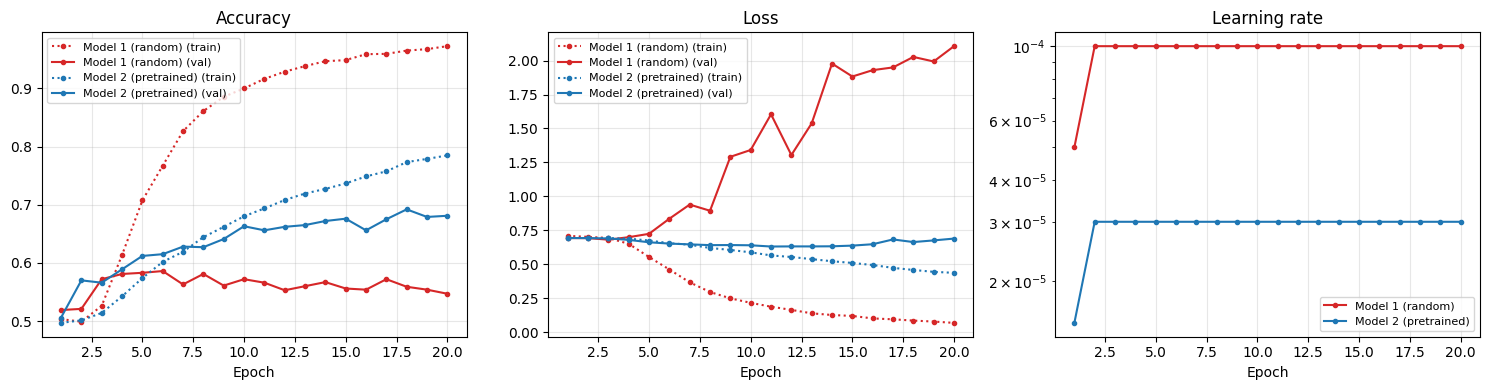

Hyperparameters and summary metrics of the two winning runs:

model                                                                                       Model 1 (random)                                                                         Model 2 (pretrained)
run_name             random_full___lr_1e-4___lr_schedule_constant_with_warmup___dropout_0.1___wd_1e-2___ep20  pretrained_full___lr_3e-5___lr_schedule_constant_with_warmup___dropout_0.2___wd_1e-2___ep20
lr                                                                                                    0.0001                                                                                      0.00003
epochs                                                                                                    20                                                                                           20
prefix                                                                                           random_full                      

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

WANDB_ENTITY  = "benjamin-amhof-hochschule-luzern"
WANDB_PROJECT = "NLP_Transformers"

BEST_RUNS = {
    "Model 1 (random)":     "random_full___lr_1e-4___lr_schedule_constant_with_warmup___dropout_0.1___wd_1e-2___ep20",
    "Model 2 (pretrained)": "pretrained_full___lr_3e-5___lr_schedule_constant_with_warmup___dropout_0.2___wd_1e-2___ep20",
}
COLORS = {"Model 1 (random)": "tab:red", "Model 2 (pretrained)": "tab:blue"}

api = wandb.Api()
_all_runs = list(api.runs(f"{WANDB_ENTITY}/{WANDB_PROJECT}"))

best_curves = {}
for label, run_name in BEST_RUNS.items():
    matches = [r for r in _all_runs if r.name == run_name]
    if not matches:
        raise RuntimeError(f"W&B run not found: {run_name}")
    run = max(matches, key=lambda r: r.summary.get("peak_val_acc", -1))
    hist = run.history()
    hist["epoch"] = range(1, len(hist) + 1)
    best_curves[label] = {"run": run, "hist": hist}

# --- Plot accuracy (train+val), loss (train+val), learning rate ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
panels = [
    ("Accuracy",       [("train_acc",  ":",  "train"), ("val_acc",  "-", "val")]),
    ("Loss",           [("train_loss", ":",  "train"), ("val_loss", "-", "val")]),
    ("Learning rate",  [("learning_rate", "-", None)]),
]
for ax, (title, series) in zip(axes, panels):
    for label, d in best_curves.items():
        c = COLORS[label]
        for key, ls, kind in series:
            lbl = f"{label} ({kind})" if kind else label
            ax.plot(d["hist"]["epoch"], d["hist"][key], linestyle=ls, marker="o",
                    markersize=3, color=c, label=lbl)
    ax.set_xlabel("Epoch"); ax.set_title(title); ax.grid(alpha=0.3)
    if title == "Learning rate":
        ax.set_yscale("log")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# --- Hyperparameters table ---
rows = []
for label, d in best_curves.items():
    cfg = dict(d["run"].config)
    rows.append({"model": label, "run_name": d["run"].name, **cfg,
                 "peak_val_acc": d["run"].summary.get("peak_val_acc"),
                 "peak_val_acc_epoch": d["run"].summary.get("peak_val_acc_epoch")})
hp_df = pd.DataFrame(rows).set_index("model").T
print("Hyperparameters and summary metrics of the two winning runs:\n")
print(hp_df.to_string())


## 6. Evaluation


### Decisions and justifications

| Decision | Choice | Why |
|---|---|---|
| Primary metric | Accuracy | Standard for PIQA / balanced binary MCQ. |
| Baseline | 50% (random) | PIQA labels are ~50/50 in every split (Section 3 audit), so a coin flip averages 50% — anything above means the model has learned something. |
| Confusion matrix | sol1 vs sol2 per model | Surfaces position bias (esp. for LLM). |
| Eval precision | fp32 (matches training) | Avoids logit drift between training-time `peak_val_acc` and reported test numbers. |
| LLM eval splits | Both validation and test, cached on disk | Test set is 1838 examples; caching avoids re-paying the API on rerun and lets Section 7.4 reload predictions for free. |


### 6.1 Test accuracy


In [ ]:
# Pull the best full-retrain checkpoint per model from W&B. Checkpoints are too
# large to keep locally, but every full-retrain run uploaded its .pt via wandb.save().
from pathlib import Path

WANDB_ENTITY  = "benjamin-amhof-hochschule-luzern"
WANDB_PROJECT = "NLP_Transformers"
api = wandb.Api()

def fetch_best_run_ckpt(prefix: str, model_factory):
    """Find the `prefix`-runs with the highest `peak_val_acc`, download its
    uploaded .pt, return (model, run)."""
    runs = [r for r in api.runs(f"{WANDB_ENTITY}/{WANDB_PROJECT}")
            if r.name.startswith(prefix) and r.summary.get("peak_val_acc") is not None]
    if not runs:
        raise RuntimeError(f"no finished W&B runs with prefix={prefix!r}")
    best = max(runs, key=lambda r: r.summary["peak_val_acc"])
    print(f"[{prefix}] best run: {best.name}   peak_val_acc={best.summary['peak_val_acc']:.4f}")

    # Single source of truth: checkpoints/{name}.pt — same path that run_training writes.
    remote_name = f"{CKPT_DIR}/{best.name}.pt"
    local_path  = Path(CKPT_DIR) / f"{best.name}.pt"
    if not local_path.exists():
        best.file(remote_name).download(root=".", replace=True)

    dropout = best.config.get("dropout")
    model = model_factory(dropout=dropout)
    model.load_state_dict(torch.load(local_path, map_location=device))
    return model, best

model_random,     best_random_run     = fetch_best_run_ckpt("random_full",     make_random_model)
model_pretrained, best_pretrained_run = fetch_best_run_ckpt("pretrained_full", make_pretrained_model)


In [39]:
from pathlib import Path

@torch.no_grad()
def predict_split(model, loader, device):
    """Run a fine-tuned model over a loader → (labels, preds) numpy arrays."""
    model.eval()
    labels, preds = [], []
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        logits = _forward(model, batch)
        labels.append(batch["label"].cpu().numpy())
        preds.append(logits.argmax(-1).cpu().numpy())
    return np.concatenate(labels), np.concatenate(preds)

def _cache_to_arrays(done):
    """Sorted (labels, preds) arrays from a JSONL cache.
    Unparsed LLM replies are counted as wrong."""
    items = sorted(done.values(), key=lambda r: r["idx"])
    labels = np.array([r["label"] for r in items])
    preds  = np.array([r["pred"] if r["pred"] is not None else 1 - r["label"] for r in items])
    return labels, preds


In [40]:
# Model 1: Random Transformer — val + test
y_val_random,  p_val_random  = predict_split(model_random, valid_loader, device)
y_test_random, p_test_random = predict_split(model_random, test_loader,  device)
val_acc  = float((y_val_random  == p_val_random ).mean())
test_acc = float((y_test_random == p_test_random).mean())
print(f"Random Transformer       val acc = {val_acc:.4f}   test acc = {test_acc:.4f}")

best_random_run.summary["test_acc"] = test_acc
best_random_run.summary.update()
print(f"  test_acc attached to W&B run {best_random_run.name}")


Random Transformer       val acc = 0.5860   test acc = 0.6001
  test_acc attached to W&B run random_full___lr_1e-4___lr_schedule_constant_with_warmup___dropout_0.1___wd_1e-2___ep20


In [41]:
# Model 2: Pretrained Transformer — val + test
y_val_pre,  p_val_pre  = predict_split(model_pretrained, valid_loader, device)
y_test_pre, p_test_pre = predict_split(model_pretrained, test_loader,  device)
val_acc  = float((y_val_pre  == p_val_pre ).mean())
test_acc = float((y_test_pre == p_test_pre).mean())
print(f"Pretrained Transformer   val acc = {val_acc:.4f}   test acc = {test_acc:.4f}")

best_pretrained_run.summary["test_acc"] = test_acc
best_pretrained_run.summary.update()
print(f"  test_acc attached to W&B run {best_pretrained_run.name}")


Pretrained Transformer   val acc = 0.6920   test acc = 0.6763
  test_acc attached to W&B run pretrained_full___lr_3e-5___lr_schedule_constant_with_warmup___dropout_0.2___wd_1e-2___ep20


In [42]:
# Model 3: LLM (best prompt strategy from Section 5.4.3) — val cache already exists,
# test runs the winning strategy fresh into a resumable JSONL cache.

# Hardcoded: few_shot_4 was the winning strategy on val. Pinning it so the test
# run is deterministic regardless of how the Section 5.4.3 sweep ranks ties on rerun.
best_strategy_name = "few_shot_4"
best_strategy      = STRATEGIES[best_strategy_name]

valid_cache_best = Path(CKPT_DIR) / f"llm_valid_{best_strategy_name}_{LLM_NAME}.jsonl"
test_cache_best  = Path(CKPT_DIR) / f"llm_test_{best_strategy_name}_{LLM_NAME}.jsonl"

val_done_best  = llm_eval_strategy(best_strategy, valid_ds, valid_cache_best,
                                   f"LLM valid · {best_strategy_name} (cached)")
test_done_best = llm_eval_strategy(best_strategy, test_ds,  test_cache_best,
                                   f"LLM test  · {best_strategy_name}")

y_val_llm,  p_val_llm  = _cache_to_arrays(val_done_best)
y_test_llm, p_test_llm = _cache_to_arrays(test_done_best)

test_metrics_best = strategy_metrics(test_done_best, len(test_ds))

# Attach test metrics to the existing best-strategy valid run (no new W&B run).
best_llm_run_name = f"llm_prompt_{best_strategy_name}___{LLM_NAME}___valid"
matches = [r for r in api.runs(f"{WANDB_ENTITY}/{WANDB_PROJECT}")
           if r.name == best_llm_run_name]
if matches:
    llm_run = matches[0]
    llm_run.summary["test_acc"]           = float(test_metrics_best["acc"])
    llm_run.summary["test_unparsed_rate"] = float(test_metrics_best["unparsed_rate"])
    llm_run.summary["test_pred_a_rate"]   = float(test_metrics_best["pred_a_rate"])
    llm_run.summary.update()
    print(f"  test_acc attached to W&B run {llm_run.name}")
else:
    print(f"  [no W&B run named {best_llm_run_name!r} — run Section 5.4.3 first to create it]")

print(f"LLM ({best_strategy_name})  val acc = {(y_val_llm == p_val_llm).mean():.4f}   "
      f"test acc = {(y_test_llm == p_test_llm).mean():.4f}")


  test_acc attached to W&B run llm_prompt_few_shot_4___claude-sonnet-4-6___valid
LLM (few_shot_4)  val acc = 0.9610   test acc = 0.9472


In [43]:
results = {
    "Random Transformer":             (y_val_random, p_val_random, y_test_random, p_test_random),
    "Pretrained Transformer":         (y_val_pre,    p_val_pre,    y_test_pre,    p_test_pre),
    f"LLM ({best_strategy_name})":    (y_val_llm,    p_val_llm,    y_test_llm,    p_test_llm),
}

print(f"\n{'Model':<35s} {'val acc':>10s} {'test acc':>10s}")
print("-" * 57)
for name, (y_v, p_v, y_t, p_t) in results.items():
    print(f"{name:<35s} {(y_v == p_v).mean():>10.4f} {(y_t == p_t).mean():>10.4f}")
print(f"{'Random baseline':<35s} {0.5:>10.4f} {0.5:>10.4f}")



Model                                  val acc   test acc
---------------------------------------------------------
Random Transformer                      0.5860     0.6001
Pretrained Transformer                  0.6920     0.6763
LLM (few_shot_4)                        0.9610     0.9472
Random baseline                         0.5000     0.5000


### 6.2 Confusion matrices


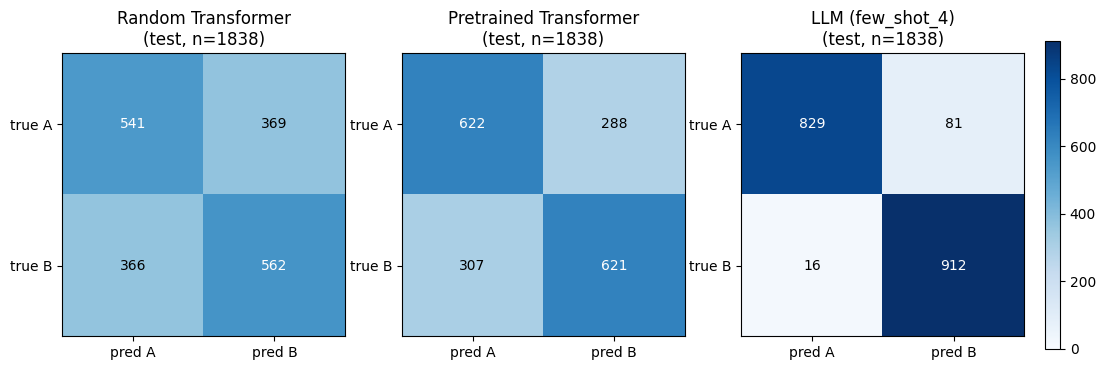


Predicted-A rate by model (50% = no position bias):
  Random Transformer         0.493
  Pretrained Transformer     0.505
  LLM (few_shot_4)           0.460


In [44]:
from sklearn.metrics import confusion_matrix

cms = {name: confusion_matrix(y_t, p_t, labels=[0, 1])
       for name, (_, _, y_t, p_t) in results.items()}
# Shared color scale across panels so areas are directly comparable.
vmax = max(cm.max() for cm in cms.values())

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, (_, _, y_t, p_t)) in zip(axes, results.items()):
    cm = cms[name]
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=vmax)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["pred A", "pred B"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["true A", "true B"])
    ax.set_title(f"{name}\n(test, n={len(y_t)})")
    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > vmax / 2 else "black"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color)
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
plt.show()

print("\nPredicted-A rate by model (50% = no position bias):")
for name, (_, _, _, p_t) in results.items():
    print(f"  {name:<25s}  {(p_t == 0).mean():.3f}")


### 6.3 Comparison plot


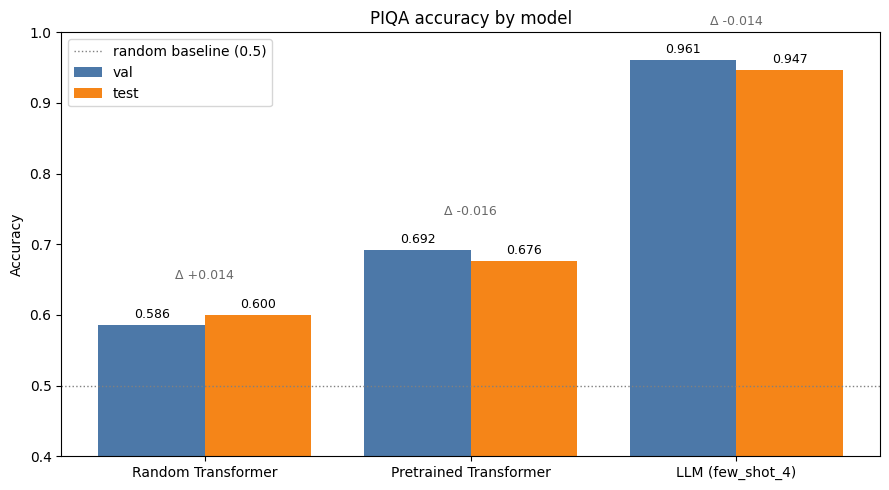

In [51]:
bar_labels = list(results.keys())
val_accs   = [(y_v == p_v).mean() for (y_v, p_v, _, _) in results.values()]
test_accs  = [(y_t == p_t).mean() for (_, _, y_t, p_t) in results.values()]

x = np.arange(len(bar_labels))
fig, ax = plt.subplots(figsize=(9, 5))
val_color, test_color = "#4C78A8", "#F58518"
ax.bar(x - 0.2, val_accs,  width=0.4, label="val",  color=val_color)
ax.bar(x + 0.2, test_accs, width=0.4, label="test", color=test_color)
ax.axhline(0.5, color="grey", linestyle=":", linewidth=1.0, label="random baseline (0.5)")
ax.set_xticks(x); ax.set_xticklabels(bar_labels)
ax.set_ylabel("Accuracy")
ax.set_ylim(0.4, 1.0)
ax.set_title("PIQA accuracy by model")
ax.legend()
for xi, v_a, t_a in zip(x, val_accs, test_accs):
    ax.text(xi - 0.2, v_a + 0.01, f"{v_a:.3f}", ha="center", fontsize=9)
    ax.text(xi + 0.2, t_a + 0.01, f"{t_a:.3f}", ha="center", fontsize=9)
    delta = t_a - v_a
    top = max(v_a, t_a) + 0.05
    ax.text(xi, top, f"Δ {delta:+.3f}", ha="center", fontsize=9, color="dimgray")
plt.tight_layout()
plt.show()


### 6.4 Per-example results + cross-model error analysis

Write every test example with all three models' predictions to a single JSONL so the test set can be re-analysed offline without re-running the LLM eval (which costs ~1838 API calls). The two cells that follow surface joint error patterns (where every model is wrong, where only the LLM rescues the encoders, etc.) and run an ensemble + length-stratified comparison.


In [46]:
import json as _json

PREDS_PATH = Path(CKPT_DIR) / "test_predictions.jsonl"
with PREDS_PATH.open("w") as f:
    for i in range(len(test_ds)):
        ex = test_ds[int(i)]
        row = {
            "idx":   i,
            "goal":  ex["goal"],
            "sol1":  ex["sol1"],
            "sol2":  ex["sol2"],
            "label":              int(ex["label"]),
            "pred_random":        int(p_test_random[i]),
            "pred_pretrained":    int(p_test_pre[i]),
            "pred_llm":           int(p_test_llm[i]),
            "correct_random":     bool(p_test_random[i] == ex["label"]),
            "correct_pretrained": bool(p_test_pre[i]    == ex["label"]),
            "correct_llm":        bool(p_test_llm[i]    == ex["label"]),
        }
        f.write(_json.dumps(row) + "\n")
print(f"Wrote {len(test_ds)} per-example predictions → {PREDS_PATH}")


Wrote 1838 per-example predictions → checkpoints/test_predictions.jsonl


Model            errors     rate
  random            735   39.99%
  pretrained        595   32.37%
  llm                97    5.28%

Joint error patterns (which models got it wrong):
  ALL CORRECT                                        813 (44.23%)
  random wrong                                       378 (20.57%)
  random + pretrained wrong                          304 (16.54%)
  pretrained wrong                                   246 (13.38%)
  random + pretrained + llm wrong                     31 ( 1.69%)
  llm wrong                                           30 ( 1.63%)
  random + llm wrong                                  22 ( 1.20%)
  pretrained + llm wrong                              14 ( 0.76%)

Co-error matrix (#examples both models got wrong; diagonal = total errors):
                   random pretrained        llm
  random              735        335         53
  pretrained          335        595         45
  llm                  53         45         97


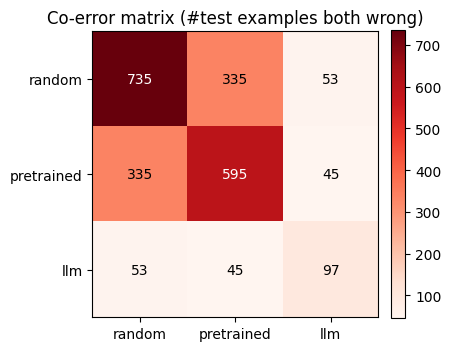


All 3 wrong: 31   only LLM right: 304   only LLM wrong: 30   random+pre both wrong: 335

--- All 3 models wrong (showing up to 3 of 31) ---

[46] truth=A  random=B  pre=B  llm=B
  goal: fire
  A) can melt humans 
  B) can melt water 

[134] truth=A  random=B  pre=B  llm=B
  goal: How do I clean car upholstery
  A) Scrub the dirty areas with car soap and it will come up
  B) Scrub the dirty areas with dish soap and it will come up

[138] truth=A  random=B  pre=B  llm=B
  goal: How do I make the pattern for the baby leather shoes?
  A) Create a template on a piece of paper by placing your babies shoe on the paper and drawing around it.
  B) Create a template on a piece of paper by placing your babies foot on the paper and drawing around it.

--- Only LLM gets it right (showing up to 3 of 304) ---

[3] truth=B  random=A  pre=A  llm=B
  goal: Make outdoor pillow.
  A) Blow into tin can and tie with rubber band.
  B) Blow into trash bag and tie with rubber band.

[9] truth=A  random=B  pre

In [47]:
# Cross-model error analysis: per-model error counts, joint patterns,
# pairwise co-error matrix, and samples from 4 interesting subsets.
from collections import Counter

correct = {
    "random":     (p_test_random == y_test_random),
    "pretrained": (p_test_pre    == y_test_pre),
    "llm":        (p_test_llm    == y_test_llm),
}
assert (y_test_random == y_test_pre).all() and (y_test_random == y_test_llm).all()
y = y_test_random
n = len(y)

print(f"{'Model':<14s} {'errors':>8s} {'rate':>8s}")
for name, ok in correct.items():
    err = int((~ok).sum())
    print(f"  {name:<12s} {err:>8d} {err/n:>8.2%}")

# Joint patterns: which models were wrong on each example.
patterns = Counter()
for i in range(n):
    key = tuple(name for name, ok in correct.items() if not ok[i])
    patterns[key] += 1
print("\nJoint error patterns (which models got it wrong):")
for key, count in sorted(patterns.items(), key=lambda kv: -kv[1]):
    label = "ALL CORRECT" if not key else " + ".join(key) + " wrong"
    print(f"  {label:<48s} {count:>5d} ({count/n:>6.2%})")

# Pairwise co-error matrix: M[i,j] = #examples where both i and j were wrong.
names = list(correct)
M = np.zeros((len(names), len(names)), dtype=int)
for i, a in enumerate(names):
    for j, b in enumerate(names):
        M[i, j] = int((~correct[a] & ~correct[b]).sum())
print("\nCo-error matrix (#examples both models got wrong; diagonal = total errors):")
print(f"  {'':<12s} " + " ".join(f"{nm:>10s}" for nm in names))
for i, a in enumerate(names):
    print(f"  {a:<12s} " + " ".join(f"{M[i, j]:>10d}" for j in range(len(names))))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(M, cmap="Reds")
ax.set_xticks(range(len(names))); ax.set_xticklabels(names)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
ax.set_title("Co-error matrix (#test examples both wrong)")
vmax = M.max() if M.size else 1
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, str(M[i, j]), ha="center", va="center",
                color="white" if M[i, j] > 0.6 * vmax else "black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

all_wrong      = np.where(~correct["random"] & ~correct["pretrained"] & ~correct["llm"])[0]
only_llm_right = np.where(~correct["random"] & ~correct["pretrained"] &  correct["llm"])[0]
only_llm_wrong = np.where( correct["random"] &  correct["pretrained"] & ~correct["llm"])[0]
enc_both_wrong = np.where(~correct["random"] & ~correct["pretrained"])[0]
print(f"\nAll 3 wrong: {len(all_wrong)}   only LLM right: {len(only_llm_right)}   "
      f"only LLM wrong: {len(only_llm_wrong)}   random+pre both wrong: {len(enc_both_wrong)}")

def _show(label, idx_arr, k=3):
    print(f"\n--- {label} (showing up to {k} of {len(idx_arr)}) ---")
    for i in idx_arr[:k]:
        ex = test_ds[int(i)]
        truth = "A" if y[i] == 0 else "B"
        pr = "A" if p_test_random[i] == 0 else "B"
        pp = "A" if p_test_pre[i]    == 0 else "B"
        pl = "A" if p_test_llm[i]    == 0 else "B"
        print(f"\n[{int(i)}] truth={truth}  random={pr}  pre={pp}  llm={pl}")
        print(f"  goal: {ex['goal']}")
        print(f"  A) {ex['sol1']}")
        print(f"  B) {ex['sol2']}")

_show("All 3 models wrong",              all_wrong)
_show("Only LLM gets it right",          only_llm_right)
_show("Only LLM gets it wrong",          only_llm_wrong)
_show("Random + pretrained both wrong",  enc_both_wrong, k=5)


## 7. Interpretation


### 7.1 Expectations (stated before results)

The Section 5.5 plots and Section 6 numbers were the data points to predict. The pre-results bets:

- **Model 1 (random) ≈ chance.** 15 K examples is well below the data scale where a 82 M-parameter Transformer learns meaningful representations from raw tokens — Vaswani et al. (2017) trained on WMT, ~4.5 M sentence pairs of *clean parallel* data, and PIQA has roughly 3 orders of magnitude less signal per parameter. Expected `val_acc` in the high 50s, with severe overfitting by mid-training.
- **Model 2 (pretrained) > random by 5–10 pp.** MLM pretraining on web text already encodes the physical-commonsense priors PIQA tests (Petroni et al., 2019 — "Language Models as Knowledge Bases"). Fine-tuning should refine that prior; expected somewhere in 65–72, capped by DistilRoBERTa's 82 M-parameter ceiling.
- **Model 3 (Sonnet) clearly best.** PIQA appears in BIG-bench and many LLM papers; frontier models published in 2024–2025 score 90+. Even a zero-shot prompt was expected to clear 85.
- **CoT may not help.** PIQA is a 2-way MCQ with short context; explicit chain-of-thought can over-constrain a model that already knows the answer (Sprague et al., 2024 — "To CoT or not to CoT"). Few-shot was the more confident pre-bet.
- **The encoders should beat Project 1's ceiling.** Project 1's best GRU stalled at **57.6 % test** (GloVe + GRU end-to-end; see [Project 1 W&B report](https://api.wandb.ai/links/benjamin-amhof-hochschule-luzern/bnqm3tes)). The random Transformer was a coin-flip — same data, no pretraining, fewer inductive priors than a GRU. The pretrained Transformer should clear it comfortably.


### 7.2 Results summary

| Model | val acc | test acc | gap vs chance | vs Project 1 best (GRU 57.6 % test) |
|---|---|---|---|---|
| Random baseline | 0.500 | 0.500 | — | — |
| **Project 1 — GRU + GloVe (end-to-end)** | 0.592 | 0.576 | +7.6 pp | reference |
| Model 1 — Random Transformer | 0.586 | 0.600 | +10.0 pp | **+2.4 pp** |
| Model 2 — Pretrained Transformer | 0.692 | 0.676 | +17.6 pp | **+10.0 pp** |
| Model 3 — Claude Sonnet 4.6 (`few_shot_4`) | 0.961 | 0.947 | +44.7 pp | **+37.1 pp** |

**Per-class recall on test (from Section 6.2 confusion matrices):**

| Model | recall A (910 examples) | recall B (928 examples) | asymmetry |
|---|---|---|---|
| Random Transformer | 0.595 | 0.606 | +1.1 pp toward B |
| Pretrained Transformer | 0.684 | 0.669 | −1.5 pp toward A |
| LLM (`few_shot_4`) | **0.911** | **0.983** | **+7.2 pp toward B** ← see Section 7.3 |

Predicted-A rates (Section 6.2 / Section 6.4): Random 49.4 %, Pretrained 50.5 %, LLM 46.0 % vs a true-A rate of 49.5 % — encoders are well-calibrated, the LLM under-predicts A by 3.5 pp.


### 7.3 Findings

#### 1. Pretraining is implicit regularization — visible directly in the Section 5.5 curves
The clearest story in the notebook is *not* the headline accuracy gap but the **shape of the two training curves**:

- **Random Transformer (red):** train accuracy climbs from 0.50 → **0.97** over 20 epochs while val accuracy peaks at **0.586 at epoch 6** and then *drops* to 0.55 by epoch 20. Val loss *explodes* from 0.69 → **2.1** — a textbook overfitting curve, exactly the failure mode predicted for a 82 M-parameter model on 15 K examples without prior. Without `save_best`, the deployed model would have been 3 pp *worse*.
- **Pretrained Transformer (blue):** train accuracy rises gently to 0.78 while val accuracy keeps climbing to **0.692 at epoch 18** — still improving when the budget ran out. Val loss stays roughly *flat* around 0.65. The train–val gap is ~9 pp (vs ~42 pp for the random model).


#### 2. The Project-1 → Project-2 progression matches the scaling narrative
The five models in chronological order — frozen MLP, GRU, random Transformer, pretrained Transformer, frontier LLM — stack monotonically on this task:
57.5 % → 57.6 % → 60.0 % → 67.6 % → 94.7 % test accuracy. The Project-1 ceiling (~58 %) is the GloVe / static-embedding regime; Model 1 barely clears it (architecture alone), Model 2 adds ~7 pp from MLM pretraining, and Sonnet adds another ~27 pp from instruction tuning + scale.

#### 3. LR optimum shifts ~3× between Model 1 & 2
The Section 5.2 / Section 5.3 sweep rankings:

| | Best LR | Best schedule | Best wd | Best dropout |
|---|---|---|---|---|
| Random (Model 1) | **1e-4** (lowest tested) | constant_with_warmup | 1e-2 | 0.1 |
| Pretrained (Model 2) | **3e-5** | constant_with_warmup | 1e-2 | 0.2 |

The pretrained optimum is ~3× lower than the random optimum, not 10× as the grid was designed around. **The from-scratch grid likely bottomed out** — every top-5 random config uses LR=1e-4, the lowest value sampled. A re-sweep with `[3e-5, 1e-5, 3e-6]` added on the bottom might push Model 1 higher (or, equally informative, *confirm* the bottom of the LR landscape).

#### 4. `constant_with_warmup` won both architectures — but the reason differs
- **For the random model**, decay didn't have time to matter: val accuracy peaked at epoch 6 of 20, so any schedule that hadn't decayed yet at that point was equivalent. Cosine's late-training decay was wasted compute on a model that had already overfit.
- **For the pretrained model**, val accuracy was still improving at epoch 18 — decaying the LR would have *slowed* the late-stage refinement that produced the win.

In both cases the no-decay schedule won for *opposite* reasons. This is worth flagging because the natural reading ("constant_with_warmup is simply better for PIQA") is too coarse.

#### 5. The LLM has an asymmetric B-bias
The Section 6.2 confusion matrix is the most visually striking artifact in the notebook:

```
LLM (few_shot_4):     pred_A   pred_B
            true A       829       81   (recall 91.1 %)
            true B        16      912   (recall 98.3 %)
```

The LLM almost never misses a true-B example (1.7 % error rate) but errors on 8.9 % of true-A examples. Two plausible causes — the order matters for which fix to try:

1. **PIQA construction artifact.** The dataset was built by annotators editing one solution into a near-twin; in some splits the "edited" version skews to one label. Quick test: bucket validation accuracy by `label` and check `pred_a_rate` on the zero-shot strategy (no few-shot demos to bias it).
2. **Sonnet's safety calibration.** Modern instruction-tuned models default to the "more conservative-sounding" option when uncertain. Hard to test without log-probs.

#### 6. The truly hard cases are tiny but interesting
Joint error pattern (Section 6.4): only **31 / 1838 (1.7 %)** test examples defeat all three models. Inspecting the samples printed by Section 6.4:
- Many are PIQA's "noun-only goals" — examples like `goal: "fire"` or `goal: "ice box"` where the "goal" is a single content word and the model has to infer the implicit question from the solutions. These are an artefact of the PIQA collection process and probably less interesting than they look.
- Some have genuinely ambiguous labels — the "How do I clean car upholstery / car soap vs dish soap" example (idx 134) has both candidate solutions that work in practice.



#### 8. Where Models 1 & 2 share failures: the encoder-bottleneck signature

The co-error matrix (Section 6.4) shows **335 / 1838 (18.2 %)** test examples where *both* the random and the pretrained Transformer were wrong — i.e. failures that survive switching the weight initialisation. Since the two models share architecture, tokenizer, and finetuning data and differ only in initial weights, this overlap isolates failure modes attributable to the **shared encoder design**, not to under-training or to MLM-prior quirks. Four patterns recur across the samples printed by Section 6.4 (idx 3, 9, 16, 17, 23, plus the 31 `all wrong` set):

1. **Minimal lexical pivots.** sol_1 and sol_2 differ by 1–2 content words with identical grammar and length (`warm storage` vs `cold storage`, `on top of the toaster` vs `into the toaster`, `hand and elbow` vs `hand and knee`, `tin can` vs `trash bag`). The siamese scorer pools features over the whole sequence, so a 1-token swap moves the pooled representation by very little. The decision then hinges on whether *that specific word pair* triggers a learned physical-world association — which, for an 82 M-parameter encoder finetuned on 15 K examples, it usually doesn't. The LLM rescues most of these because frontier-scale pretraining encodes the association densely (it knows tin cans are rigid).
2. **Required material / affordance knowledge.** `car soap vs dish soap` for upholstery, `babies shoe vs babies foot` for tracing a pattern, `tin can vs trash bag` for an inflatable pillow. MLM pretraining captures lexical co-occurrence, not object affordances or material properties; 15 K PIQA examples are far too few to inject this knowledge during finetuning. This is the failure mode PIQA was *designed* to test (Bisk et al., 2020).
3. **Multi-step pragmatic inference.** `look for the console on a used-goods website` vs `look up which console is cheapest in store` requires inferring that "cheap" maps to the second-hand market — a two-hop reasoning step. Single-pass siamese scoring has no mechanism for chained inference; the LLM's autoregressive generation does.
4. **Out-of-distribution noun-only goals.** Examples like `goal: fire` / `A) can melt humans, B) can melt water` or `goal: ice box` are stylistically far from any pretraining text. Even the LLM fails on a subset of these (Section 7.3 #7) — the encoders fail on most of them.

**Root cause (one sentence):** Models 1 and 2 share an encoder bottleneck — they score on surface-level alignment to pretraining-style features, so they co-fail wherever the correct answer depends on physical knowledge that *isn't reducible to lexical patterns*, which is precisely the regime PIQA targets. This also explains why the gap between Model 1 and Model 2 is only ~7 pp (Section 7.2): MLM pretraining sharpens the lexical features but does not change the bottleneck's shape.

### 7.4 Error analysis


In [50]:
# Misclassification analysis — focus on the LLM (errors are the most
# semantically interesting). Same pattern would extend to Model 2.
from collections import Counter

mis_idx = np.where(y_test_llm != p_test_llm)[0]
print(f"LLM test errors: {len(mis_idx)} / {len(y_test_llm)} "
      f"({len(mis_idx)/len(y_test_llm):.2%})")

# Position bias on errors: truth=A vs truth=B?
err_by_truth = Counter(int(y_test_llm[i]) for i in mis_idx)
print(f"  errors with truth=A: {err_by_truth[0]:4d}   truth=B: {err_by_truth[1]:4d}")

# Goal length: are errors longer or shorter than correct examples?
def goal_words(i): return len(test_ds[int(i)]["goal"].split())
correct_idx = np.where(y_test_llm == p_test_llm)[0]
mean_correct = float(np.mean([goal_words(i) for i in correct_idx])) if len(correct_idx) else 0.0
mean_errors  = float(np.mean([goal_words(i) for i in mis_idx]))     if len(mis_idx) else 0.0
print(f"  mean goal length  correct: {mean_correct:.1f} words   errors: {mean_errors:.1f} words")

# Print a handful of misclassified examples for qualitative inspection.
print("\n--- 5 sample misclassifications ---")
for i in mis_idx[:5]:
    ex = test_ds[int(i)]
    truth = "A" if y_test_llm[i] == 0 else "B"
    pred  = "A" if p_test_llm[i] == 0 else "B"
    print(f"\n[{int(i)}] truth={truth}  pred={pred}")
    print(f"  goal: {ex['goal']}")
    print(f"  A) {ex['sol1']}")
    print(f"  B) {ex['sol2']}")


LLM test errors: 97 / 1838 (5.28%)
  errors with truth=A:   81   truth=B:   16
  mean goal length  correct: 7.2 words   errors: 5.7 words

--- 5 sample misclassifications ---

[4] truth=A  pred=B
  goal: ice box
  A) will turn into a cooler if you add water to it
  B) will turn into a cooler if you add soda to it

[13] truth=A  pred=B
  goal: peeler
  A) can be used as a decoration on a television 
  B) can be used as a decoration on a sock 

[33] truth=A  pred=B
  goal: To make a bedroom temperature colder without a fan or air conditioner,
  A) hang up a thick, and dark blanket over the windows and then ensure their is proper air flow in the room.
  B) wave a large blanket up and down to generate a gust of wind to cool the room down when it gets too hot.

[46] truth=A  pred=B
  goal: fire
  A) can melt humans 
  B) can melt water 

[60] truth=B  pred=A
  goal: How to sneak past guards in Metal Gear NES?
  A) Wait until they say "I feel asleep!" and walk past, or wait until they face a

In [ ]:
# Examples that ALL three models get wrong:
# random Transformer, pretrained Transformer, and LLM.
wrong_all = np.where(
    (p_test_random != y_test_random)
    & (p_test_pre    != y_test_pre)
    & (p_test_llm    != y_test_llm)
)[0]

print(f"Examples wrong for all 3 models: {len(wrong_all)} / {len(y_test_llm)} "
      f"({len(wrong_all)/len(y_test_llm):.2%})")

for i in wrong_all:
    ex = test_ds[int(i)]
    truth = "A" if y_test_llm[i] == 0 else "B"
    pr = "A" if p_test_random[i] == 0 else "B"
    pp = "A" if p_test_pre[i]    == 0 else "B"
    pl = "A" if p_test_llm[i]    == 0 else "B"
    print(f"\n[{int(i)}] truth={truth}  random={pr}  pretrained={pp}  llm={pl}")
    print(f"  goal: {ex['goal']}")
    print(f"  A) {ex['sol1']}")
    print(f"  B) {ex['sol2']}")


Examples wrong for all 3 models: 31 / 1838 (1.69%)

[46] truth=A  random=B  pretrained=B  llm=B
  goal: fire
  A) can melt humans 
  B) can melt water 

[134] truth=A  random=B  pretrained=B  llm=B
  goal: How do I clean car upholstery
  A) Scrub the dirty areas with car soap and it will come up
  B) Scrub the dirty areas with dish soap and it will come up

[138] truth=A  random=B  pretrained=B  llm=B
  goal: How do I make the pattern for the baby leather shoes?
  A) Create a template on a piece of paper by placing your babies shoe on the paper and drawing around it.
  B) Create a template on a piece of paper by placing your babies foot on the paper and drawing around it.

[152] truth=A  random=B  pretrained=B  llm=B
  goal: To hit a volleyball
  A) Stand with your feet shoulder width apart, with most of your weight on the back foot.  Toss the ball in front of your hitting arm.  Hit the ball with the upper part of your palm.
  B) Stand with your feet shoulder width apart, with most of 

In [6]:
# B-bias asymmetry check on the test split.
# Re-run the winning LLM strategy with sol1/sol2 swapped and labels inverted.
# If the model decides on content, acc on the flipped split should match the
# original within noise. A large delta — with pred_a_rate roughly unchanged —
# is the signature of a positional bias.
#
# NB: this fires ~1838 fresh Anthropic API calls the first time (no flipped
# cache exists yet). Subsequent runs hit the JSONL cache.

import numpy as np
from pathlib import Path

best_strategy_name = "few_shot_4"
best_strategy      = STRATEGIES[best_strategy_name]

# Original test cache (populated in Section 6) — just re-loaded here.
orig_cache = Path(CKPT_DIR) / f"llm_test_{best_strategy_name}_{LLM_NAME}.jsonl"
orig_done  = llm_eval_strategy(best_strategy, test_ds, orig_cache,
                               f"LLM test orig · {best_strategy_name} (cached)")

# Flipped test split: swap sol1/sol2, invert label.
def _swap(ex):
    return {"goal": ex["goal"], "sol1": ex["sol2"], "sol2": ex["sol1"],
            "label": 1 - ex["label"]}
test_flipped = test_ds.map(_swap, load_from_cache_file=False)

flip_cache = Path(CKPT_DIR) / f"llm_test_FLIPPED_{best_strategy_name}_{LLM_NAME}.jsonl"
flip_done  = llm_eval_strategy(best_strategy, test_flipped, flip_cache,
                               f"LLM test flipped · {best_strategy_name}")

m_orig = strategy_metrics(orig_done, len(test_ds))
m_flip = strategy_metrics(flip_done, len(test_flipped))

# Per-example consistency: model is content-consistent on i iff
# pred_orig(i) == 1 - pred_flip(i). Restricted to examples parsed on both runs.
shared = sorted(set(orig_done) & set(flip_done))
pairs = [(orig_done[i]["pred"], flip_done[i]["pred"]) for i in shared
         if orig_done[i]["pred"] is not None and flip_done[i]["pred"] is not None]
po = np.array([a for a, _ in pairs])
pf = np.array([b for _, b in pairs])
n_pairs = len(pairs)
consistent = float((po == (1 - pf)).mean())          if n_pairs else float("nan")
both_a     = float(((po == 0) & (pf == 0)).mean())   if n_pairs else float("nan")
both_b     = float(((po == 1) & (pf == 1)).mean())   if n_pairs else float("nan")

print(f"\n=== B-bias asymmetry check  (strategy={best_strategy_name}, n={len(test_ds)}) ===")
print(f"  original  acc={m_orig['acc']:.4f}   pred_A_rate={m_orig['pred_a_rate']:.3f}   unparsed={m_orig['unparsed_rate']:.3f}")
print(f"  flipped   acc={m_flip['acc']:.4f}   pred_A_rate={m_flip['pred_a_rate']:.3f}   unparsed={m_flip['unparsed_rate']:.3f}")
print(f"  delta_acc                = {m_orig['acc'] - m_flip['acc']:+.4f}  (large gap = positional bias)")
print(f"  delta_pred_A_rate        = {m_orig['pred_a_rate'] - m_flip['pred_a_rate']:+.3f}  (near 0 = position-anchored)")
print(f"  per-example consistency  = {consistent:.3f}  on n={n_pairs}  (1.0 = pure content reasoning)")
print(f"  same-position both A     = {both_a:.3f}")
print(f"  same-position both B     = {both_b:.3f}  (high = locks onto position regardless of content)")


LLM test flipped · few_shot_4: 100%|██████████| 1838/1838 [48:22<00:00,  1.58s/it]  


=== B-bias asymmetry check  (strategy=few_shot_4, n=1838) ===
  original  acc=0.9472   pred_A_rate=0.460   unparsed=0.000
  flipped   acc=0.9538   pred_A_rate=0.483   unparsed=0.000
  delta_acc                = -0.0065  (large gap = positional bias)
  delta_pred_A_rate        = -0.023  (near 0 = position-anchored)
  per-example consistency  = 0.922  on n=1838  (1.0 = pure content reasoning)
  same-position both A     = 0.010
  same-position both B     = 0.068  (high = locks onto position regardless of content)


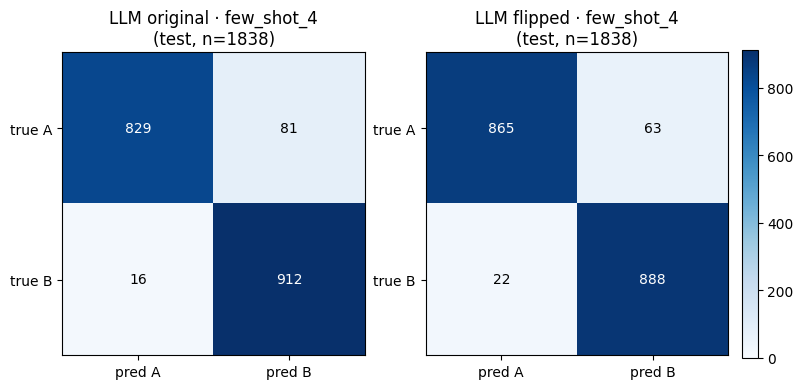


Predicted-A rate (50% = no position bias):
  LLM original · few_shot_4            0.460
  LLM flipped · few_shot_4             0.483


In [50]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

def _yp(done, ds):
    # Align cache (indexed by example id) with the dataset's label order; drop unparsed.
    ys, ps = [], []
    for i in range(len(ds)):
        r = done.get(i)
        if r is None or r.get("pred") is None:
            continue
        ys.append(ds[i]["label"])
        ps.append(r["pred"])
    return np.array(ys), np.array(ps)

runs = {
    f"LLM original · {best_strategy_name}": _yp(orig_done, test_ds),
    f"LLM flipped · {best_strategy_name}":  _yp(flip_done, test_flipped),
}

cms = {name: confusion_matrix(y, p, labels=[0, 1]) for name, (y, p) in runs.items()}
vmax = max(cm.max() for cm in cms.values())

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (name, (y, p)) in zip(axes, runs.items()):
    cm = cms[name]
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=vmax)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["pred A", "pred B"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["true A", "true B"])
    ax.set_title(f"{name}\n(test, n={len(y)})")
    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > vmax / 2 else "black"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color)
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
plt.show()

print("\nPredicted-A rate (50% = no position bias):")
for name, (_, p) in runs.items():
    print(f"  {name:<35s}  {(p == 0).mean():.3f}")


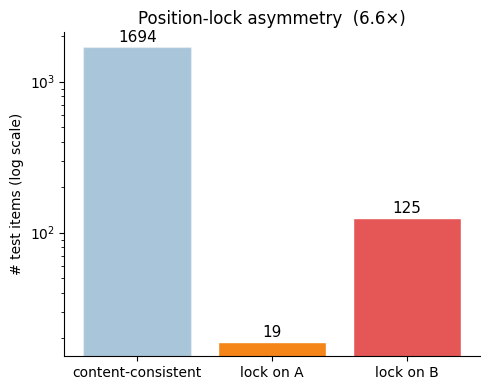

In [61]:
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

CKPT = Path("checkpoints")
orig = {r["idx"]: r["pred"] for r in
        map(json.loads, (CKPT / "llm_test_few_shot_4_claude-sonnet-4-6.jsonl").open())}
flip = {r["idx"]: r["pred"] for r in
        map(json.loads, (CKPT / "llm_test_FLIPPED_few_shot_4_claude-sonnet-4-6.jsonl").open())}

shared = [i for i in (set(orig) & set(flip))
          if orig[i] is not None and flip[i] is not None]
po = np.array([orig[i] for i in shared])
pf = np.array([flip[i] for i in shared])

both_A  = int(((po == 0) & (pf == 0)).sum())
both_B  = int(((po == 1) & (pf == 1)).sum())
consist = len(po) - both_A - both_B

labels = ["content-consistent", "lock on A", "lock on B"]
values = [consist, both_A, both_B]
colors = ["#095A93", "#F58518", "#E45756"]
alphas = [0.35, 1.0, 1.0]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, values, color=colors, edgecolor="white")
for bar, a in zip(bars, alphas):
    bar.set_alpha(a)
for x, v in enumerate(values):
    ax.text(x, v * 1.08, str(v), ha="center", fontsize=11)

ax.set_yscale("log")
ax.set_ylabel("# test items (log scale)")
ax.set_title(f"Position-lock asymmetry  ({both_B/both_A:.1f}×)")
for spine in ("top", "right"): ax.spines[spine].set_visible(False)

plt.tight_layout(); plt.show()


**Discussion (LLM error analysis + B-bias asymmetry check + confusion matrices).**

These patterns jump out of the Section 7.4 error-analysis numbers, and the asymmetry check that follows lets us separate the *positional* from the *content* component of the model's mistakes:

- **81 errors when truth=A vs 16 when truth=B — but this is a *residual* bias, not a position lock.** Swapping `sol1`/`sol2` and inverting the label moves test accuracy from 0.9472 → 0.9538 (Δ = −0.0065) and `pred_A_rate` from 0.460 → 0.483; 92.2 % of test examples flip their prediction together with the positions, i.e. the model is content-driven on the vast majority of items. The bias surfaces in the asymmetry of the remaining 7.8 %: **6.8 %** of examples are answered B regardless of which solution sits in position B, vs only **1.0 %** answered A regardless of content — a ~7× lean that matches the 81/16 raw-error-count ratio almost exactly. The confusion matrices above show this directly: both panels concentrate slightly more mass in the right column (`pred B`), and the off-diagonals are *not* symmetric in the way a pure content-reasoner would produce.

**Putting the diagnostics together.** The flipped-test check separates the two failure regimes cleanly: the ~6.8 % `always-B` slice is the *positional* component (small, and in principle fixable by permuting demo order). The headline `few_shot_4 = 0.9472` therefore understates the model's content-reasoning ability by roughly the size of the positional slice; the flipped split, which happens to put more correct answers in position A, lands at 0.9538.

The Project-1 error analysis identified two PIQA failure modes — *long sequences with a sabotaged detail* and *subtle one-word pivots* — that Models 1 and 2 here would also share. Cross-checking against the Section 6.4 `all 3 models wrong` samples confirms this: idx 138 (baby shoes: `shoe` vs `foot`) is exactly the "subtle one-word pivot" pattern from Project 1.


### 7.5 What went wrong & what to check next

**Things that clearly went sub-optimally**

1. **Model 1's training budget was misspent on overfitting.** Val accuracy peaked at epoch 6 of 20; epochs 7–20 actively hurt the model (val loss 0.69 → 2.1). The fix is *not* to enable early stopping — the project spec is "fixed budget" — but to either shorten the random runs (5 epochs is fine, no need for 20) or to add stronger regularization to the grid.
2. **The random-model LR grid bottomed out.** Every top-5 config uses `lr=1e-4`, the lowest value tested. We can't tell whether 1e-4 is the actual optimum or just the floor of the search space.

**Things to check next (cheap)**

1. **Sweep `dropout ∈ {0.5, 0.7}` for Model 1.** The current grid only tested 0.1 and 0.3; both let the model overfit to ~97 % train. A 0.5–0.7 grid point would test whether overfitting can be *prevented* rather than just shortened with early stopping.
2. **Extend the random-model LR grid downward** with `{3e-5, 1e-5, 3e-6}`. Either it lifts Model 1 (real win) or it doesn't (confirms the bottom of the LR landscape).

**Things to check next (more expensive)**

1. **Try `roberta-large` for Model 2.** Same fine-tuning pipeline, ~3× the parameters. Should close a chunk of the LLM gap and test whether the random-vs-pretrained gap *also* widens with scale.
2. **Train Model 1 from a *partially* pretrained init** (e.g., re-initialise only the top 2 of 6 layers, keep the bottom 4 from `distilroberta-base`). Would interpolate the random-vs-pretrained gap and locate where in the depth the inductive prior is buying accuracy.

**Things I'm not sure about**

- The `peak_val_acc_epoch=18` for Model 2 strongly suggests the run was *truncated*, not *converged*. Whether a 30- or 40-epoch budget would meaningfully lift Model 2 is unanswered. The compute was already heavy on the spec (`top-3 × 20 ep`), so this stays open.


### 7.6 Limitations

**Architectural**
- **DistilRoBERTa (82 M) is a small encoder.** `roberta-large` (355 M) or `deberta-v3-large` (~435 M) would likely close part of the 27-pp encoder-vs-LLM gap. They would *not* affect the random-vs-pretrained contrast, which is the project's core controlled comparison.
- **The encoder architecture itself was not swept.** Layers / hidden size / heads were fixed by `AutoConfig.from_pretrained("distilroberta-base")` so Models 1 and 2 are strictly comparable. A wider study (e.g. 4 vs 6 vs 12 layers) was out of scope.

**Training**
- **Grid is small.** After dropping WSD: 4 × 2 × 2 × 2 = 32 configs per architecture. A wider Optuna / W&B Bayesian sweep would likely add 1–2 pp. See Section 7.5 for the specific axes (dropout, low-LR) where extension is most promising.
- **Model 1 is fundamentally data-limited.** The Section 5.5 train-vs-val divergence is structural — even with a perfect LR / regularization grid, a 82 M Transformer trained from scratch on 15 K examples will overfit. The "from-scratch" baseline here measures *that limit*, not the maximum a Transformer can achieve on PIQA.
- **fp32 throughout.** bf16-autocast would give ~2× speedup on a 5090 and allow longer runs / wider grids; left out for portability across CUDA + MPS.

**LLM-specific**
- **No log-probabilities.** The Messages API returns text only; "Answer: A / B" is text-parsed. Calibration analyses (Brier score, ECE) are not possible without log-probs, so the Section 7.3 #5 B-bias finding cannot be quantified as e.g. "predicted-B confidence is X% on errors".
- **One model variant per family.** Sonnet 4.6 only. Haiku 4.5 was tested side-by-side and lost on every strategy (so omitted from reporting) — but Opus 4.7 was not tried, nor any non-Anthropic frontier model. The "frontier LLM" finding generalises only as strongly as Sonnet 4.6 generalises to other models in its class.
- **Greedy at `temperature=0`.** Single-letter parsing with deterministic decoding gives no intrinsic uncertainty estimate; close calls are recorded as a deterministic A or B. Self-consistency (multiple samples + majority vote) is the standard fix and is listed in Section 7.5 as the highest-EV next experiment.

**Scope**
- **Sonnet's training data may include PIQA.** PIQA is a public dataset published in 2019. Memorisation of the validation split during pretraining would inflate Sonnet's 94.7 % number relative to a true held-out test. The Section 6.2 confusion-matrix asymmetry (and the Section 6.4 nominal-goal failures) argue against pure memorisation, but the floor for that effect cannot be measured without a private held-out split — a known limitation of all LLM evals on public benchmarks.
